## Código ordenado: modelo de regresión lineal con comuna, hora, día, cantidad de paquetes, etc.

In [1]:
#Librerías
import pandas as pd
import numpy as np

In [2]:
# Los datos cargados en este bloque consideran dos empresas: Falabella (32849) y CoAndina (80058)

# Datos gps son todos los puntos lat,lon de trayectoria gps de vehículos entre el 22 y 29 de septiembre de 2025
gps = pd.read_csv("gps.csv")
# Datos visitas son todos los puntos lat,lon de paradas programadas + lat,lon checkouts 
visitas = pd.read_csv("visitas2.csv")

In [3]:
# Separamos los datos por empresa tanto para gps como para visitas
gps_falabella = gps[gps["account_id"]== 32849].copy()
gps_CoAndina = gps[gps["account_id"]== 80058].copy()

visitas_falabella = visitas[visitas["account_id"]== 32849].copy()
visitas_CoAndina = visitas[visitas["account_id"]== 80058].copy()

In [4]:
## Debemos agregar variable día de la semana, para poder modificar el código en adelante, a traves de la columna DIA
import pandas as pd

# Asegurar que created sea datetime con zona horaria
gps_falabella["created"] = pd.to_datetime(gps_falabella["created"], utc=True)

# Crear columna con nombre del día en español
dias = {
    "Monday": "lunes",
    "Tuesday": "martes",
    "Wednesday": "miércoles",
    "Thursday": "jueves",
    "Friday": "viernes",
    "Saturday": "sábado",
    "Sunday": "domingo"
}

gps_falabella["dia"] = gps_falabella["created"].dt.day_name().map(dias)
gps_22 = gps_falabella

In [5]:
import pandas as pd

visitas_falabella["event_date"] = pd.to_datetime(
    visitas_falabella["event_date"],
    format="mixed",
    utc=True
)

# Diccionario días en español

dias = {
    "Monday": "lunes",
    "Tuesday": "martes",
    "Wednesday": "miércoles",
    "Thursday": "jueves",
    "Friday": "viernes",
    "Saturday": "sábado",
    "Sunday": "domingo"
}

# Crear columna día (en UTC)
visitas_falabella["dia"] = visitas_falabella["event_date"].dt.day_name().map(dias)
visitas_F22 = visitas_falabella

In [6]:
THRESHOLD = 0.1
MAX_MINUTES = 5

gps_22["created"] = pd.to_datetime(gps_22["created"], errors="coerce", utc=True)
gps_22["battery_level"] = pd.to_numeric(gps_22["battery_level"], errors="coerce")

gps_22 = gps_22.dropna(subset=["owner_id", "created", "battery_level"])

# Día en hora Chile
dias = {
    "Monday": "lunes",
    "Tuesday": "martes",
    "Wednesday": "miércoles",
    "Thursday": "jueves",
    "Friday": "viernes",
    "Saturday": "sábado",
    "Sunday": "domingo"
}

gps_22["created_cl"] = gps_22["created"].dt.tz_convert("America/Santiago")
gps_22["dia"] = gps_22["created_cl"].dt.day_name().map(dias)

# Orden correcto
gps_22 = gps_22.sort_values(["owner_id", "dia", "created_cl"])

# Total de rutas reales de la semana
rutas_totales = (
    gps_22[["owner_id", "dia"]]
    .drop_duplicates()
)

total_rutas_semana = len(rutas_totales)

# Diferencias dentro de cada ruta owner_id-día
gps_22["battery_jump"] = (
    gps_22.groupby(["owner_id", "dia"])["battery_level"]
    .diff()
)

gps_22["time_diff_min"] = (
    gps_22.groupby(["owner_id", "dia"])["created_cl"]
    .diff()
    .dt.total_seconds() / 60
)

# Ruta sospechosa si dentro de ese owner_id-día hay salto raro
gps_22["is_suspicious_jump"] = (
    (gps_22["battery_jump"].abs() > THRESHOLD) &
    (gps_22["time_diff_min"] < MAX_MINUTES)
)

# Rutas sospechosas owner_id-día
rutas_sospechosas = (
    gps_22.loc[gps_22["is_suspicious_jump"], ["owner_id", "dia"]]
    .drop_duplicates()
)

total_rutas_sospechosas = len(rutas_sospechosas)

# Owner_id que fueron sospechosos más de un día
owner_sospechosos_mas_de_un_dia = (
    rutas_sospechosas
    .groupby("owner_id")["dia"]
    .nunique()
    .reset_index(name="dias_sospechosos")
    .query("dias_sospechosos > 1")
)

# Eliminar SOLO las rutas owner_id-día sospechosas
gps_22_limpio = (
    gps_22
    .merge(
        rutas_sospechosas.assign(ruta_sospechosa=1),
        on=["owner_id", "dia"],
        how="left"
    )
)

gps_22_limpio = gps_22_limpio[gps_22_limpio["ruta_sospechosa"].isna()].copy()
gps_22_limpio = gps_22_limpio.drop(columns=["ruta_sospechosa"])

# Rutas finales limpias
rutas_limpias = (
    gps_22_limpio[["owner_id", "dia"]]
    .drop_duplicates()
)

print(f"Rutas totales semana: {total_rutas_semana}")
print(f"Rutas sospechosas eliminadas: {total_rutas_sospechosas}")
print(f"Rutas limpias finales: {len(rutas_limpias)}")
print(f"Owner_id sospechosos más de un día: {len(owner_sospechosos_mas_de_un_dia)}")

C:\Users\j4vic\AppData\Local\Temp\ipykernel_28908\847414644.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gps_22["created_cl"] = gps_22["created"].dt.tz_convert("America/Santiago")
C:\Users\j4vic\AppData\Local\Temp\ipykernel_28908\847414644.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gps_22["dia"] = gps_22["created_cl"].dt.day_name().map(dias)


Rutas totales semana: 4110
Rutas sospechosas eliminadas: 1768
Rutas limpias finales: 2342
Owner_id sospechosos más de un día: 436


In [7]:
# =========================================================
# AGRUPAR CHECKOUTS EN "PARADAS REALIZADAS"
# Criterio:
# - mismo user_id
# - mismo día
# - ordenados por event_date
# - misma parada si siguen dentro de un radio de 10 m
#   respecto al ancla de la parada actual
# =========================================================

import pandas as pd
import numpy as np

RANGO_PARADA_M = 10

# Normalizar tipos por seguridad
visitas_F22["user_id"] = pd.to_numeric(visitas_F22["user_id"], errors="coerce")
visitas_F22["event_date"] = pd.to_datetime(
    visitas_F22["event_date"],
    errors="coerce",
    utc=True
)
visitas_F22["latitude_1"] = pd.to_numeric(visitas_F22["latitude_1"], errors="coerce")
visitas_F22["longitude_1"] = pd.to_numeric(visitas_F22["longitude_1"], errors="coerce")

# Eliminar filas incompletas
visitas_F22 = visitas_F22.dropna(
    subset=["user_id", "event_date", "latitude_1", "longitude_1"]
).copy()

visitas_F22["user_id"] = visitas_F22["user_id"].astype(int)

# 2) Crear fecha/hora en Chile y día de la semana
visitas_F22["event_date_cl"] = visitas_F22["event_date"].dt.tz_convert("America/Santiago")

dias = {
    "Monday": "lunes",
    "Tuesday": "martes",
    "Wednesday": "miércoles",
    "Thursday": "jueves",
    "Friday": "viernes",
    "Saturday": "sábado",
    "Sunday": "domingo"
}

visitas_F22["dia"] = visitas_F22["event_date_cl"].dt.day_name().map(dias)

# 3) Ordenar por usuario, día y tiempo
df = visitas_F22.sort_values(
    ["user_id", "dia", "event_date_cl"]
).reset_index(drop=True)

# 4) Función Haversine
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000  # radio de la Tierra en metros

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

# 5) Agrupar por usuario y día usando ancla geográfica
dfs_reducidos = []

for (user_id, dia), grupo in df.groupby(["user_id", "dia"], sort=False):
    grupo = grupo.copy().reset_index(drop=False)

    parada_ids = []
    dist_anchor_list = []

    parada_actual = 0

    # Ancla inicial de la primera parada del usuario-día
    anchor_lat = grupo.loc[0, "latitude_1"]
    anchor_lon = grupo.loc[0, "longitude_1"]

    parada_ids.append(parada_actual)
    dist_anchor_list.append(0.0)

    for i in range(1, len(grupo)):
        lat_i = grupo.loc[i, "latitude_1"]
        lon_i = grupo.loc[i, "longitude_1"]

        dist_anchor = haversine_m(anchor_lat, anchor_lon, lat_i, lon_i)

        # Si sigue dentro de 10 m del ancla, misma parada
        if dist_anchor <= RANGO_PARADA_M:
            parada_ids.append(parada_actual)
            dist_anchor_list.append(dist_anchor)
        else:
            # Nueva parada
            parada_actual += 1
            anchor_lat = lat_i
            anchor_lon = lon_i

            parada_ids.append(parada_actual)
            dist_anchor_list.append(0.0)

    grupo["parada_id"] = parada_ids
    grupo["dist_anchor_m"] = dist_anchor_list

    # ID global de parada realizada considerando user_id + día
    grupo["paradas_realizadas"] = (
        grupo["user_id"].astype(str)
        + "_"
        + grupo["dia"].astype(str)
        + "_PR_"
        + grupo["parada_id"].astype(str)
    )

    # Reducir: dejar una fila representativa por parada realizada
    reducido = (
        grupo.groupby("paradas_realizadas", as_index=False)
        .agg(
            user_id=("user_id", "first"),
            dia=("dia", "first"),
            event_date_inicio=("event_date_cl", "min"),
            event_date_fin=("event_date_cl", "max"),
            latitude_1=("latitude_1", "mean"),
            longitude_1=("longitude_1", "mean"),
            n_checkouts_agrupados=("paradas_realizadas", "size")
        )
    )

    reducido["filas_eliminables"] = reducido["n_checkouts_agrupados"] - 1

    dfs_reducidos.append(reducido)

# 6) DataFrame final de paradas realizadas comprimidas
paradas_reales = pd.concat(dfs_reducidos, ignore_index=True)

# Duración de la parada realizada
paradas_reales["duracion_min"] = (
    (paradas_reales["event_date_fin"] - paradas_reales["event_date_inicio"])
    .dt.total_seconds() / 60
)

# Ordenar resultado final
paradas_reales = paradas_reales.sort_values(
    ["user_id", "dia", "event_date_inicio"]
).reset_index(drop=True)

print("Shape original visitas_F22:", visitas_F22.shape)
print("Shape reducido paradas_reales:", paradas_reales.shape)
print(paradas_reales.head())

Shape original visitas_F22: (1819345, 29)
Shape reducido paradas_reales: (164095, 10)
  paradas_realizadas  user_id    dia                event_date_inicio  \
0  323655_lunes_PR_0   323655  lunes 2025-09-29 09:22:35.015000-03:00   
1  323655_lunes_PR_1   323655  lunes 2025-09-29 09:27:22.532000-03:00   
2  323655_lunes_PR_2   323655  lunes 2025-09-29 09:39:38.744000-03:00   
3  323655_lunes_PR_3   323655  lunes 2025-09-29 09:40:10.127000-03:00   
4  323655_lunes_PR_4   323655  lunes 2025-09-29 09:40:48.031000-03:00   

                    event_date_fin  latitude_1  longitude_1  \
0 2025-09-29 09:23:01.156000-03:00  -33.479643   -70.662165   
1 2025-09-29 09:27:22.532000-03:00  -33.479620   -70.658073   
2 2025-09-29 09:39:41.081000-03:00  -33.480425   -70.654033   
3 2025-09-29 09:40:10.127000-03:00  -33.480268   -70.654231   
4 2025-09-29 09:42:26.487000-03:00  -33.480533   -70.653708   

   n_checkouts_agrupados  filas_eliminables  duracion_min  
0                      3            

In [8]:
# ORDENAR GPS Y CALCULAR DISTANCIA / TIEMPO / VELOCIDAD
# Considerando ruta = owner_id + día

import pandas as pd
import numpy as np

gps_F22 = gps_22_limpio

# Normalizar tipos
gps_F22["created"] = pd.to_datetime(gps_F22["created"], errors="coerce", utc=True)
gps_F22["latitude"] = pd.to_numeric(gps_F22["latitude"], errors="coerce")
gps_F22["longitude"] = pd.to_numeric(gps_F22["longitude"], errors="coerce")

# Eliminar filas incompletas
gps_F22 = gps_F22.dropna(subset=["owner_id", "created", "latitude", "longitude"]).copy()

# Crear fecha/hora Chile y día
gps_F22["created_cl"] = gps_F22["created"].dt.tz_convert("America/Santiago")

dias = {
    "Monday": "lunes",
    "Tuesday": "martes",
    "Wednesday": "miércoles",
    "Thursday": "jueves",
    "Friday": "viernes",
    "Saturday": "sábado",
    "Sunday": "domingo"
}

gps_F22["dia"] = gps_F22["created_cl"].dt.day_name().map(dias)

# Asegurar orden correcto por ruta: owner_id + día + tiempo
gps_F22 = gps_F22.sort_values(
    ["owner_id", "dia", "created_cl"]
).reset_index(drop=True)

# Función Haversine en metros
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000  # radio de la Tierra en metros

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

# Coordenadas anteriores dentro de cada ruta owner_id + día
gps_F22["prev_latitude"] = gps_F22.groupby(["owner_id", "dia"])["latitude"].shift(1)
gps_F22["prev_longitude"] = gps_F22.groupby(["owner_id", "dia"])["longitude"].shift(1)
gps_F22["prev_created"] = gps_F22.groupby(["owner_id", "dia"])["created_cl"].shift(1)

# Distancia entre punto actual y punto anterior dentro de la misma ruta
gps_F22["dist_prev_m"] = haversine_m(
    gps_F22["prev_latitude"],
    gps_F22["prev_longitude"],
    gps_F22["latitude"],
    gps_F22["longitude"]
)

# Diferencia de tiempo en segundos
gps_F22["time_diff_sec"] = (
    (gps_F22["created_cl"] - gps_F22["prev_created"])
    .dt.total_seconds()
)

# Diferencia de tiempo en minutos
gps_F22["time_diff_min_calc"] = gps_F22["time_diff_sec"] / 60

# Velocidad en m/s
gps_F22["speed_m_s"] = gps_F22["dist_prev_m"] / gps_F22["time_diff_sec"]

# Velocidad en km/h
gps_F22["speed_kmh"] = gps_F22["speed_m_s"] * 3.6

# Evitar infinitos cuando time_diff_sec = 0
gps_F22.loc[~np.isfinite(gps_F22["speed_m_s"]), "speed_m_s"] = np.nan
gps_F22.loc[~np.isfinite(gps_F22["speed_kmh"]), "speed_kmh"] = np.nan

print("Columnas creadas:")
print([
    "created_cl", "dia",
    "prev_latitude", "prev_longitude", "prev_created",
    "dist_prev_m", "time_diff_sec", "time_diff_min_calc",
    "speed_m_s", "speed_kmh"
])

Columnas creadas:
['created_cl', 'dia', 'prev_latitude', 'prev_longitude', 'prev_created', 'dist_prev_m', 'time_diff_sec', 'time_diff_min_calc', 'speed_m_s', 'speed_kmh']


In [9]:
# BLOQUE 2: DETECCIÓN DE PARADA EN VENTANA DE 1 MINUTOS
# Criterio:
# si en 1 minutos el vehículo recorre menos de 100 metros, lo consideramos parada
# Unidad de análisis: ruta = owner_id + día

STOP_WINDOW_SEC = 60
STOP_MAX_DIST_M = 100

# Asegurar orden correcto por ruta
gps_F22 = gps_F22.sort_values(["owner_id", "dia", "created_cl"]).reset_index(drop=True)

# Columnas auxiliares
gps_F22["stop_ref_idx"] = np.nan
gps_F22["stop_ref_created"] = pd.NaT
gps_F22["stop_window_dist_m"] = np.nan
gps_F22["stop_window_time_sec"] = np.nan
gps_F22["is_stop_point"] = False

# Procesar por owner_id + día
for (owner_id, dia), idx in gps_F22.groupby(["owner_id", "dia"]).groups.items():
    idx = np.array(list(idx))
    grupo = gps_F22.loc[idx].copy()

    tiempos = grupo["created_cl"].values.astype("datetime64[ns]")
    latitudes = grupo["latitude"].values
    longitudes = grupo["longitude"].values

    j = 0
    stop_ref_idx = np.full(len(grupo), np.nan)
    stop_ref_created = np.full(len(grupo), np.datetime64("NaT"), dtype="datetime64[ns]")
    stop_window_dist_m = np.full(len(grupo), np.nan)
    stop_window_time_sec = np.full(len(grupo), np.nan)
    is_stop_point = np.full(len(grupo), False)

    for i in range(len(grupo)):
        if j < i + 1:
            j = i + 1

        while j < len(grupo):
            delta_sec = (tiempos[j] - tiempos[i]) / np.timedelta64(1, "s")
            if delta_sec >= STOP_WINDOW_SEC:
                break
            j += 1

        if j < len(grupo):
            delta_sec = (tiempos[j] - tiempos[i]) / np.timedelta64(1, "s")

            dist_m = haversine_m(
                latitudes[i],
                longitudes[i],
                latitudes[j],
                longitudes[j]
            )

            stop_ref_idx[i] = idx[j]
            stop_ref_created[i] = tiempos[j]
            stop_window_dist_m[i] = dist_m
            stop_window_time_sec[i] = delta_sec
            is_stop_point[i] = dist_m < STOP_MAX_DIST_M

    gps_F22.loc[idx, "stop_ref_idx"] = stop_ref_idx
    gps_F22.loc[idx, "stop_ref_created"] = stop_ref_created
    gps_F22.loc[idx, "stop_window_dist_m"] = stop_window_dist_m
    gps_F22.loc[idx, "stop_window_time_sec"] = stop_window_time_sec
    gps_F22.loc[idx, "is_stop_point"] = is_stop_point

print("Resumen de puntos evaluados como parada:")
print(gps_F22["is_stop_point"].value_counts(dropna=False))

Resumen de puntos evaluados como parada:
is_stop_point
False    1479257
True      372390
Name: count, dtype: int64


In [10]:
# CHEQUEO RÁPIDO

columnas_revision = [
    "owner_id",
    "created",
    "latitude",
    "longitude",
    "stop_ref_idx",
    "stop_window_time_sec",
    "stop_window_dist_m",
    "is_stop_point"
]

gps_F22[columnas_revision].head(20)

,owner_id,created,latitude,longitude,stop_ref_idx,stop_window_time_sec,stop_window_dist_m,is_stop_point
0,324024,2025-09-25 12:46:38+00:00,-18.398928,-70.286865,1.0,1205.0,2126.654665,False
1,324024,2025-09-25 13:06:43+00:00,-18.401340,-70.306860,30.0,582.0,2839.559513,False
2,324024,2025-09-25 13:06:43+00:00,-18.401340,-70.306860,30.0,582.0,2839.559513,False
3,324024,2025-09-25 13:06:43+00:00,-18.401340,-70.306860,30.0,582.0,2839.559513,False
4,324024,2025-09-25 13:06:43+00:00,-18.401340,-70.306860,30.0,582.0,2839.559513,False
5,324024,2025-09-25 13:06:43+00:00,-18.401340,-70.306860,30.0,582.0,2839.559513,False
6,324024,2025-09-25 13:06:43+00:00,-18.401340,-70.306860,30.0,582.0,2839.559513,False
7,324024,2025-09-25 13:06:43+00:00,-18.401340,-70.306860,30.0,582.0,2839.559513,False
8,324024,2025-09-25 13:06:43+00:00,-18.401340,-70.306860,30.0,582.0,2839.559513,False
9,324024,2025-09-25 13:06:43+00:00,-18.401340,-70.306860,30.0,582.0,2839.559513,False


In [11]:
# =========================================================
# BLOQUE 4: AGRUPAR PUNTOS CONSECUTIVOS DE PARADA
# Unidad de análisis: ruta = owner_id + día
# =========================================================

gps_F22 = gps_F22.copy()

# Asegurar orden correcto
gps_F22 = gps_F22.sort_values(
    ["owner_id", "dia", "created_cl"]
).reset_index(drop=True)

gps_F22["stop_state_change"] = (
    gps_F22.groupby(["owner_id", "dia"])["is_stop_point"]
    .transform(lambda s: s.ne(s.shift(1)))
)

gps_F22["stop_segment_raw"] = (
    gps_F22.groupby(["owner_id", "dia"])["stop_state_change"]
    .cumsum()
)

gps_F22["stop_segment_id"] = np.where(
    gps_F22["is_stop_point"],
    (
        gps_F22["owner_id"].astype(str)
        + "_"
        + gps_F22["dia"].astype(str)
        + "_STOP_"
        + gps_F22["stop_segment_raw"].astype(str)
    ),
    np.nan
)

print("Cantidad de segmentos detectados:")
print(gps_F22["stop_segment_id"].nunique(dropna=True))

Cantidad de segmentos detectados:
87898


In [12]:
# =========================================================
# BLOQUE 5: RESUMEN DE PARADAS DETECTADAS
# =========================================================

paradas_gps_22 = (
    gps_F22[gps_F22["is_stop_point"]]
    .groupby("stop_segment_id", as_index=False)
    .agg(
        owner_id=("owner_id", "first"),
        start_time=("created", "min"),
        end_time=("created", "max"),
        n_points=("created", "size"),
        mean_latitude=("latitude", "mean"),
        mean_longitude=("longitude", "mean"),
        min_window_dist_m=("stop_window_dist_m", "min"),
        max_window_dist_m=("stop_window_dist_m", "max"),
        mean_window_dist_m=("stop_window_dist_m", "mean")
    )
)

paradas_gps_22["duration_min"] = (
    (paradas_gps_22["end_time"] - paradas_gps_22["start_time"])
    .dt.total_seconds() / 60
)

paradas_gps_22 = paradas_gps_22[
    [
        "stop_segment_id",
        "owner_id",
        "start_time",
        "end_time",
        "duration_min",
        "n_points",
        "mean_latitude",
        "mean_longitude",
        "min_window_dist_m",
        "max_window_dist_m",
        "mean_window_dist_m"
    ]
].sort_values(["owner_id", "start_time"]).reset_index(drop=True)

print("Cantidad de paradas resumidas:", len(paradas_gps_22))
paradas_gps_22.head()

Cantidad de paradas resumidas: 87898


,stop_segment_id,owner_id,start_time,end_time,duration_min,n_points,mean_latitude,mean_longitude,min_window_dist_m,max_window_dist_m,mean_window_dist_m
0,324024_lunes_STOP_1,324024,2025-09-22 13:32:32+00:00,2025-09-22 13:37:34+00:00,5.033333,4,-18.395898,-70.286179,0.000000,33.181619,15.141548
1,324024_lunes_STOP_3,324024,2025-09-22 13:43:36+00:00,2025-09-22 13:44:03+00:00,0.450000,3,-18.397802,-70.305546,16.738347,78.501111,53.604876
2,324024_lunes_STOP_5,324024,2025-09-22 14:08:09+00:00,2025-09-22 14:10:45+00:00,2.600000,6,-18.431537,-70.289944,2.438733,86.190575,50.419983
3,324024_lunes_STOP_7,324024,2025-09-22 14:12:04+00:00,2025-09-22 14:21:16+00:00,9.200000,12,-18.430354,-70.287951,10.007885,92.653043,51.031882
4,324024_lunes_STOP_9,324024,2025-09-22 14:24:25+00:00,2025-09-22 14:28:03+00:00,3.633333,11,-18.434467,-70.287277,10.771261,96.508694,55.952999


In [13]:
from keplergl import KeplerGl
import json

In [14]:
# =========================================================
# FILTRO GENERAL PREVIO:
# 1) dejar solo rutas comunes entre gps_F22 y visita_22
# 2) calcular ventana horaria real disponible en GPS por owner_id + día
# 3) filtrar visita_22 a checkouts dentro de esa ventana
# 4) re-filtrar gps_F22 a las rutas que sobreviven
# =========================================================

gps_F22 = gps_F22.copy()
visita_22 = visitas_F22.copy()

# ---------------------------------------------------------
# 1) Normalizar IDs y timestamps
# ---------------------------------------------------------
gps_F22["owner_id"] = pd.to_numeric(gps_F22["owner_id"], errors="coerce")
visita_22["user_id"] = pd.to_numeric(visita_22["user_id"], errors="coerce")

gps_F22["created"] = pd.to_datetime(gps_F22["created"], errors="coerce", utc=True)
visita_22["event_date"] = pd.to_datetime(
    visita_22["event_date"],
    errors="coerce",
    utc=True,
    format="mixed"
)

gps_F22 = gps_F22.dropna(subset=["owner_id", "created"]).copy()
visita_22 = visita_22.dropna(subset=["user_id", "event_date"]).copy()

gps_F22["owner_id"] = gps_F22["owner_id"].astype(int)
visita_22["user_id"] = visita_22["user_id"].astype(int)

# ---------------------------------------------------------
# 2) Crear fecha/hora Chile y día
# ---------------------------------------------------------
gps_F22["created_cl"] = gps_F22["created"].dt.tz_convert("America/Santiago")
visita_22["event_date_cl"] = visita_22["event_date"].dt.tz_convert("America/Santiago")

dias = {
    "Monday": "lunes",
    "Tuesday": "martes",
    "Wednesday": "miércoles",
    "Thursday": "jueves",
    "Friday": "viernes",
    "Saturday": "sábado",
    "Sunday": "domingo"
}

gps_F22["dia"] = gps_F22["created_cl"].dt.day_name().map(dias)
visita_22["dia"] = visita_22["event_date_cl"].dt.day_name().map(dias)

# ---------------------------------------------------------
# 3) Dejar solo IDs comunes inicialmente
# ---------------------------------------------------------
ids_comunes = sorted(
    set(gps_F22["owner_id"].unique()).intersection(
        set(visita_22["user_id"].unique())
    )
)

gps_F22 = gps_F22[gps_F22["owner_id"].isin(ids_comunes)].copy()
visita_22 = visita_22[visita_22["user_id"].isin(ids_comunes)].copy()

# ---------------------------------------------------------
# 4) Calcular ventana GPS por ruta: owner_id + día
# ---------------------------------------------------------
gps_window = (
    gps_F22.groupby(["owner_id", "dia"], as_index=False)
    .agg(
        gps_start_time=("created_cl", "min"),
        gps_end_time=("created_cl", "max"),
        gps_n_points=("created_cl", "size")
    )
)

# ---------------------------------------------------------
# 5) Cruzar ventana GPS con visitas por user_id + día
# ---------------------------------------------------------
visita_22 = visita_22.merge(
    gps_window,
    left_on=["user_id", "dia"],
    right_on=["owner_id", "dia"],
    how="inner"
)

# ---------------------------------------------------------
# 6) Quedarse solo con visitas dentro de la ventana GPS del mismo día
# ---------------------------------------------------------
visita_22 = visita_22[
    (visita_22["event_date_cl"] >= visita_22["gps_start_time"]) &
    (visita_22["event_date_cl"] <= visita_22["gps_end_time"])
].copy()

# ---------------------------------------------------------
# 7) Re-filtrar gps_F22 a las rutas owner_id + día que sobrevivieron
# ---------------------------------------------------------
rutas_finales = (
    visita_22[["user_id", "dia"]]
    .drop_duplicates()
    .rename(columns={"user_id": "owner_id"})
)

gps_F22 = gps_F22.merge(
    rutas_finales.assign(ruta_valida=1),
    on=["owner_id", "dia"],
    how="inner"
).drop(columns=["ruta_valida"])

visita_22 = visita_22.merge(
    rutas_finales.rename(columns={"owner_id": "user_id"}).assign(ruta_valida=1),
    on=["user_id", "dia"],
    how="inner"
).drop(columns=["ruta_valida"])

# ---------------------------------------------------------
# 8) Limpieza final y orden
# ---------------------------------------------------------
if "owner_id_y" in visita_22.columns:
    visita_22 = visita_22.drop(columns=["owner_id_y"])

if "owner_id_x" in visita_22.columns:
    visita_22 = visita_22.rename(columns={"owner_id_x": "owner_id"})

gps_F22 = gps_F22.sort_values(["owner_id", "dia", "created_cl"]).reset_index(drop=True)
visita_22 = visita_22.sort_values(["user_id", "dia", "event_date_cl"]).reset_index(drop=True)

print("=======================================")
print(f"IDs comunes iniciales: {len(ids_comunes)}")
print(f"Rutas finales owner_id + día con visitas dentro de ventana GPS: {len(rutas_finales)}")
print(f"gps_F22 shape final: {gps_F22.shape}")
print(f"visita_22 shape final: {visita_22.shape}")
print(f"owner_id únicos en gps_F22: {gps_F22['owner_id'].nunique()}")
print(f"user_id únicos en visita_22: {visita_22['user_id'].nunique()}")

print("\nMuestra de ventanas GPS por owner_id + día:")
print(gps_window.head())

IDs comunes iniciales: 763
Rutas finales owner_id + día con visitas dentro de ventana GPS: 1321
gps_F22 shape final: (1463192, 32)
visita_22 shape final: (797308, 33)
owner_id únicos en gps_F22: 571
user_id únicos en visita_22: 571

Muestra de ventanas GPS por owner_id + día:
   owner_id      dia            gps_start_time              gps_end_time  \
0    324024   jueves 2025-09-25 09:46:38-03:00 2025-09-25 20:07:42-03:00   
1    324024    lunes 2025-09-22 10:32:32-03:00 2025-09-29 13:55:14-03:00   
2    324024   martes 2025-09-23 22:32:58-03:00 2025-09-23 22:33:27-03:00   
3    324024   sábado 2025-09-27 09:55:43-03:00 2025-09-27 18:14:42-03:00   
4    324024  viernes 2025-09-26 09:37:45-03:00 2025-09-26 15:32:20-03:00   

   gps_n_points  
0           878  
1          1171  
2             3  
3           914  
4           597  


In [15]:
# =========================================================
# BLOQUE 1: PREPARAR CAPAS PARA KEPLERGL
# Considerando ruta = owner_id/user_id + día
# =========================================================

# 1) GPS completo
gps_map = gps_F22.copy()

gps_map["created"] = pd.to_datetime(gps_map["created"], errors="coerce", utc=True)

if "created_cl" not in gps_map.columns:
    gps_map["created_cl"] = gps_map["created"].dt.tz_convert("America/Santiago")

if "dia" not in gps_map.columns:
    dias = {
        "Monday": "lunes",
        "Tuesday": "martes",
        "Wednesday": "miércoles",
        "Thursday": "jueves",
        "Friday": "viernes",
        "Saturday": "sábado",
        "Sunday": "domingo"
    }
    gps_map["dia"] = gps_map["created_cl"].dt.day_name().map(dias)

gps_map = gps_map.dropna(subset=["owner_id", "dia", "latitude", "longitude"]).copy()
gps_map["tipo_capa"] = "gps_completo"

gps_map = gps_map.sort_values(
    ["owner_id", "dia", "created_cl"]
).reset_index(drop=True)


# 2) Puntos detectados como parada según el criterio actual
gps_stops_map = gps_F22[gps_F22["is_stop_point"] == True].copy()

gps_stops_map["created"] = pd.to_datetime(gps_stops_map["created"], errors="coerce", utc=True)

if "created_cl" not in gps_stops_map.columns:
    gps_stops_map["created_cl"] = gps_stops_map["created"].dt.tz_convert("America/Santiago")

if "dia" not in gps_stops_map.columns:
    gps_stops_map["dia"] = gps_stops_map["created_cl"].dt.day_name().map(dias)

gps_stops_map = gps_stops_map.dropna(subset=["owner_id", "dia", "latitude", "longitude"]).copy()
gps_stops_map["tipo_capa"] = "parada_detectada_gps"

gps_stops_map = gps_stops_map.sort_values(
    ["owner_id", "dia", "created_cl"]
).reset_index(drop=True)


# 3) Paradas realizadas desde visita_22
visitas_map = visita_22.copy()

visitas_map["user_id"] = pd.to_numeric(visitas_map["user_id"], errors="coerce")
visitas_map["event_date"] = pd.to_datetime(
    visitas_map["event_date"],
    errors="coerce",
    utc=True,
    format="mixed"
)

visitas_map = visitas_map.dropna(
    subset=["user_id", "event_date", "latitude_1", "longitude_1"]
).copy()

visitas_map["user_id"] = visitas_map["user_id"].astype(int)

if "event_date_cl" not in visitas_map.columns:
    visitas_map["event_date_cl"] = visitas_map["event_date"].dt.tz_convert("America/Santiago")

if "dia" not in visitas_map.columns:
    visitas_map["dia"] = visitas_map["event_date_cl"].dt.day_name().map(dias)

visitas_map["latitude_1"] = pd.to_numeric(visitas_map["latitude_1"], errors="coerce")
visitas_map["longitude_1"] = pd.to_numeric(visitas_map["longitude_1"], errors="coerce")

visitas_map = visitas_map.dropna(
    subset=["user_id", "dia", "latitude_1", "longitude_1", "event_date_cl"]
).copy()

visitas_map["tipo_capa"] = "parada_realizada"

visitas_map = visitas_map.sort_values(
    ["user_id", "dia", "event_date_cl"]
).reset_index(drop=True)


print(visitas_map[["user_id", "dia", "event_date_cl", "latitude_1", "longitude_1"]].head())

print("gps_map:", gps_map.shape)
print("gps_stops_map:", gps_stops_map.shape)
print("visitas_map:", visitas_map.shape)

   user_id     dia                    event_date_cl  latitude_1  longitude_1
0   324024  jueves 2025-09-25 10:26:01.728000-03:00  -18.422113   -70.291213
1   324024  jueves 2025-09-25 10:26:01.728000-03:00  -18.422113   -70.291213
2   324024  jueves 2025-09-25 10:26:01.728000-03:00  -18.422113   -70.291213
3   324024  jueves 2025-09-25 10:26:01.728000-03:00  -18.422113   -70.291213
4   324024  jueves 2025-09-25 10:26:01.728000-03:00  -18.422113   -70.291213
gps_map: (1463192, 33)
gps_stops_map: (282068, 33)
visitas_map: (797308, 34)


In [16]:
# =========================================================
# BLOQUE 2: CREAR MAPA KEPLERGL CON 3 CAPAS
# =========================================================

#mapa = KeplerGl(height=700)

#mapa.add_data(data=gps_map, name="gps_completo")
#mapa.add_data(data=gps_stops_map, name="paradas_detectadas_gps")
#mapa.add_data(data=visitas_map, name="paradas_realizadas")

#mapa

In [17]:
# =========================================================
# AGRUPAR REALIZADAS, AGRUPAR DETECTADAS, HACER MATCH Y
# DEVOLVER TABLA RESUMEN
# Considerando usuario + dia para evitar cruces entre días
# =========================================================

import pandas as pd
import numpy as np

RADIO_AGRUPACION_M = 50
RADIO_MATCH_M = 50
DIA_COL = "dia"

# ---------------------------------------------------------
# 1) Función Haversine
# ---------------------------------------------------------
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000  # metros

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c


# ---------------------------------------------------------
# 2) Función genérica para agrupar paradas por usuario + día
# ---------------------------------------------------------
def agrupar_paradas_por_ancla(
    df,
    user_col,
    time_col,
    lat_col,
    lon_col,
    radio_m,
    prefix_id,
    dia_col="dia"
):
    work = df.copy()

    work[user_col] = pd.to_numeric(work[user_col], errors="coerce")
    work[time_col] = pd.to_datetime(work[time_col], errors="coerce", utc=True)
    work[lat_col] = pd.to_numeric(work[lat_col], errors="coerce")
    work[lon_col] = pd.to_numeric(work[lon_col], errors="coerce")

    if dia_col not in work.columns:
        work[dia_col] = work[time_col].dt.day_name()

    work[dia_col] = work[dia_col].astype(str).str.lower().str.strip()

    work = work.dropna(subset=[user_col, time_col, lat_col, lon_col, dia_col]).copy()
    work[user_col] = work[user_col].astype(int)

    work = work.sort_values([user_col, dia_col, time_col]).reset_index(drop=True)

    grupos_out = []

    for (uid, dia), grupo in work.groupby([user_col, dia_col], sort=False):
        grupo = grupo.copy().reset_index(drop=True)

        anchor_lat = grupo.loc[0, lat_col]
        anchor_lon = grupo.loc[0, lon_col]
        cluster_id_actual = 0

        cluster_ids = [cluster_id_actual]
        dist_anchor_list = [0.0]

        for i in range(1, len(grupo)):
            lat_i = grupo.loc[i, lat_col]
            lon_i = grupo.loc[i, lon_col]

            dist_anchor = haversine_m(anchor_lat, anchor_lon, lat_i, lon_i)

            if dist_anchor <= radio_m:
                cluster_ids.append(cluster_id_actual)
                dist_anchor_list.append(float(dist_anchor))
            else:
                cluster_id_actual += 1
                anchor_lat = lat_i
                anchor_lon = lon_i

                cluster_ids.append(cluster_id_actual)
                dist_anchor_list.append(0.0)

        grupo["cluster_local"] = cluster_ids
        grupo["dist_anchor_m"] = dist_anchor_list

        grupo["cluster_id"] = (
            grupo[user_col].astype(str)
            + "_" + grupo[dia_col].astype(str)
            + f"_{prefix_id}_"
            + grupo["cluster_local"].astype(str)
        )

        resumen = (
            grupo.groupby("cluster_id", as_index=False)
            .agg(
                usuario=(user_col, "first"),
                dia=(dia_col, "first"),
                inicio=(time_col, "min"),
                fin=(time_col, "max"),
                lat_agrupada=(lat_col, "mean"),
                lon_agrupada=(lon_col, "mean"),
                n_filas_agrupadas=("cluster_id", "size")
            )
        )

        grupos_out.append(resumen)

    if len(grupos_out) == 0:
        return pd.DataFrame(columns=[
            "cluster_id", "usuario", "dia", "inicio", "fin",
            "lat_agrupada", "lon_agrupada", "n_filas_agrupadas"
        ])

    agrupado = pd.concat(grupos_out, ignore_index=True)

    agrupado["duracion_min"] = (
        (agrupado["fin"] - agrupado["inicio"]).dt.total_seconds() / 60
    )

    agrupado = agrupado.sort_values(["usuario", "dia", "inicio"]).reset_index(drop=True)

    return agrupado


# ---------------------------------------------------------
# 3) AGRUPADAS REALIZADAS
# ---------------------------------------------------------
paradas_agrupadas_realizadas = agrupar_paradas_por_ancla(
    df=visitas_map,
    user_col="user_id",
    time_col="event_date",
    lat_col="latitude_1",
    lon_col="longitude_1",
    radio_m=RADIO_AGRUPACION_M,
    prefix_id="REAL",
    dia_col=DIA_COL
)

paradas_agrupadas_realizadas = paradas_agrupadas_realizadas.rename(columns={
    "cluster_id": "parada_agrupada_realizada_id",
    "usuario": "user_id",
    "inicio": "event_date_inicio",
    "fin": "event_date_fin",
    "lat_agrupada": "latitude_1",
    "lon_agrupada": "longitude_1"
})

print("paradas_agrupadas_realizadas:", paradas_agrupadas_realizadas.shape)
display(paradas_agrupadas_realizadas.head())


# ---------------------------------------------------------
# 4) AGRUPADAS DETECTADAS
# ---------------------------------------------------------
paradas_agrupadas_detectadas = agrupar_paradas_por_ancla(
    df=gps_stops_map,
    user_col="owner_id",
    time_col="created",
    lat_col="latitude",
    lon_col="longitude",
    radio_m=RADIO_AGRUPACION_M,
    prefix_id="DET",
    dia_col=DIA_COL
)

paradas_agrupadas_detectadas = paradas_agrupadas_detectadas.rename(columns={
    "cluster_id": "parada_agrupada_detectada_id",
    "usuario": "owner_id",
    "inicio": "created_inicio",
    "fin": "created_fin",
    "lat_agrupada": "latitude",
    "lon_agrupada": "longitude"
})

print("paradas_agrupadas_detectadas:", paradas_agrupadas_detectadas.shape)
display(paradas_agrupadas_detectadas.head())


# ---------------------------------------------------------
# 5) MATCH 1 A 1 entre AGRUPADAS REALIZADAS y DETECTADAS
#    mismo usuario + mismo día + radio <= 50m
# ---------------------------------------------------------
def match_agrupadas_realizadas_detectadas(
    realizadas_df,
    detectadas_df,
    match_radius_m=50,
    dia_col="dia"
):
    real = realizadas_df.copy().reset_index(drop=True)
    det = detectadas_df.copy().reset_index(drop=True)

    if real.empty or det.empty:
        return pd.DataFrame(columns=[
            "parada_agrupada_realizada_id",
            "parada_agrupada_detectada_id",
            "dia",
            "user_id",
            "owner_id",
            "real_latitude_1",
            "real_longitude_1",
            "det_latitude",
            "det_longitude",
            "distance_m",
            "event_date_inicio",
            "event_date_fin",
            "created_inicio",
            "created_fin"
        ])

    real[dia_col] = real[dia_col].astype(str).str.lower().str.strip()
    det[dia_col] = det[dia_col].astype(str).str.lower().str.strip()

    candidates = []

    det_by_user_day = {
        (int(uid), dia): g.copy()
        for (uid, dia), g in det.groupby(["owner_id", dia_col], sort=False)
    }

    for _, r in real.iterrows():
        uid = int(r["user_id"])
        dia = r[dia_col]

        key = (uid, dia)

        if key not in det_by_user_day:
            continue

        cand = det_by_user_day[key]

        dists = haversine_m(
            r["latitude_1"],
            r["longitude_1"],
            cand["latitude"].values,
            cand["longitude"].values
        )

        ok = dists <= match_radius_m

        if np.any(ok):
            cand_ok = cand.loc[ok].copy()
            cand_ok["distance_m"] = dists[ok]

            for _, d in cand_ok.iterrows():
                candidates.append({
                    "parada_agrupada_realizada_id": r["parada_agrupada_realizada_id"],
                    "parada_agrupada_detectada_id": d["parada_agrupada_detectada_id"],
                    "dia": dia,
                    "user_id": r["user_id"],
                    "owner_id": d["owner_id"],
                    "real_latitude_1": r["latitude_1"],
                    "real_longitude_1": r["longitude_1"],
                    "det_latitude": d["latitude"],
                    "det_longitude": d["longitude"],
                    "distance_m": float(d["distance_m"]),
                    "event_date_inicio": r["event_date_inicio"],
                    "event_date_fin": r["event_date_fin"],
                    "created_inicio": d["created_inicio"],
                    "created_fin": d["created_fin"],
                })

    candidates_df = pd.DataFrame(candidates)

    if candidates_df.empty:
        return candidates_df

    candidates_df = candidates_df.sort_values("distance_m").reset_index(drop=True)

    used_real = set()
    used_det = set()
    selected = []

    for _, row in candidates_df.iterrows():
        real_id = row["parada_agrupada_realizada_id"]
        det_id = row["parada_agrupada_detectada_id"]

        if real_id in used_real:
            continue

        if det_id in used_det:
            continue

        used_real.add(real_id)
        used_det.add(det_id)
        selected.append(row)

    matched = pd.DataFrame(selected).reset_index(drop=True)

    return matched


paradas_agrupadas_match = match_agrupadas_realizadas_detectadas(
    realizadas_df=paradas_agrupadas_realizadas,
    detectadas_df=paradas_agrupadas_detectadas,
    match_radius_m=RADIO_MATCH_M,
    dia_col=DIA_COL
)

print("paradas_agrupadas_match:", paradas_agrupadas_match.shape)
display(paradas_agrupadas_match.head())


# ---------------------------------------------------------
# 6) TABLA RESUMEN GLOBAL
# ---------------------------------------------------------
tabla_resumen_global = pd.DataFrame([{
    "paradas_agrupadas_realizadas": paradas_agrupadas_realizadas["parada_agrupada_realizada_id"].nunique(),
    "paradas_agrupadas_detectadas": paradas_agrupadas_detectadas["parada_agrupada_detectada_id"].nunique(),
    "paradas_agrupadas_match": paradas_agrupadas_match["parada_agrupada_realizada_id"].nunique()
}])

display(tabla_resumen_global)


# ---------------------------------------------------------
# 7) TABLA RESUMEN POR USUARIO Y DÍA
# ---------------------------------------------------------
real_user_day = (
    paradas_agrupadas_realizadas.groupby(["user_id", "dia"], as_index=False)
    .agg(paradas_agrupadas_realizadas=("parada_agrupada_realizada_id", "nunique"))
    .rename(columns={"user_id": "usuario"})
)

det_user_day = (
    paradas_agrupadas_detectadas.groupby(["owner_id", "dia"], as_index=False)
    .agg(paradas_agrupadas_detectadas=("parada_agrupada_detectada_id", "nunique"))
    .rename(columns={"owner_id": "usuario"})
)

if not paradas_agrupadas_match.empty:
    match_user_day = (
        paradas_agrupadas_match.groupby(["user_id", "dia"], as_index=False)
        .agg(paradas_agrupadas_match=("parada_agrupada_realizada_id", "nunique"))
        .rename(columns={"user_id": "usuario"})
    )
else:
    match_user_day = pd.DataFrame(columns=["usuario", "dia", "paradas_agrupadas_match"])

tabla_resumen_usuario_dia = real_user_day.merge(
    det_user_day,
    on=["usuario", "dia"],
    how="outer"
)

tabla_resumen_usuario_dia = tabla_resumen_usuario_dia.merge(
    match_user_day,
    on=["usuario", "dia"],
    how="outer"
)

tabla_resumen_usuario_dia["paradas_agrupadas_realizadas"] = (
    tabla_resumen_usuario_dia["paradas_agrupadas_realizadas"].fillna(0).astype(int)
)

tabla_resumen_usuario_dia["paradas_agrupadas_detectadas"] = (
    tabla_resumen_usuario_dia["paradas_agrupadas_detectadas"].fillna(0).astype(int)
)

tabla_resumen_usuario_dia["paradas_agrupadas_match"] = (
    tabla_resumen_usuario_dia["paradas_agrupadas_match"].fillna(0).astype(int)
)

tabla_resumen_usuario_dia = tabla_resumen_usuario_dia.sort_values(
    ["paradas_agrupadas_match", "paradas_agrupadas_realizadas", "paradas_agrupadas_detectadas"],
    ascending=[False, False, False]
).reset_index(drop=True)

display(tabla_resumen_usuario_dia.head(50))


# ---------------------------------------------------------
# 8) TABLA RESUMEN POR USUARIO, SIN SEPARAR DÍA
# ---------------------------------------------------------
tabla_resumen_usuario = (
    tabla_resumen_usuario_dia
    .groupby("usuario", as_index=False)
    .agg(
        paradas_agrupadas_realizadas=("paradas_agrupadas_realizadas", "sum"),
        paradas_agrupadas_detectadas=("paradas_agrupadas_detectadas", "sum"),
        paradas_agrupadas_match=("paradas_agrupadas_match", "sum")
    )
    .sort_values(
        ["paradas_agrupadas_match", "paradas_agrupadas_realizadas", "paradas_agrupadas_detectadas"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

display(tabla_resumen_usuario.head(50))

paradas_agrupadas_realizadas: (51182, 9)


,parada_agrupada_realizada_id,user_id,dia,event_date_inicio,event_date_fin,latitude_1,longitude_1,n_filas_agrupadas,duracion_min
0,324024_jueves_REAL_0,324024,jueves,2025-09-25 13:26:01.728000+00:00,2025-09-25 13:26:01.728000+00:00,-18.422113,-70.291213,5,0.0000
1,324024_jueves_REAL_1,324024,jueves,2025-09-25 13:42:29.775000+00:00,2025-09-25 13:42:56.253000+00:00,-18.436436,-70.292660,15,0.4413
2,324024_jueves_REAL_2,324024,jueves,2025-09-25 13:56:19.700000+00:00,2025-09-25 13:56:19.700000+00:00,-18.438543,-70.296353,5,0.0000
3,324024_jueves_REAL_3,324024,jueves,2025-09-25 14:16:25.928000+00:00,2025-09-25 14:16:25.928000+00:00,-18.441551,-70.298360,5,0.0000
4,324024_jueves_REAL_4,324024,jueves,2025-09-25 14:24:05.416000+00:00,2025-09-25 14:24:05.416000+00:00,-18.440661,-70.297313,5,0.0000


paradas_agrupadas_detectadas: (130223, 9)


,parada_agrupada_detectada_id,owner_id,dia,created_inicio,created_fin,latitude,longitude,n_filas_agrupadas,duracion_min
0,324024_jueves_DET_0,324024,jueves,2025-09-25 13:37:21+00:00,2025-09-25 13:37:21+00:00,-18.436323,-70.291930,3,0.0
1,324024_jueves_DET_1,324024,jueves,2025-09-25 13:42:20+00:00,2025-09-25 13:42:20+00:00,-18.436441,-70.292660,1,0.0
2,324024_jueves_DET_2,324024,jueves,2025-09-25 13:46:39+00:00,2025-09-25 13:47:39+00:00,-18.437264,-70.295228,4,1.0
3,324024_jueves_DET_3,324024,jueves,2025-09-25 13:52:20+00:00,2025-09-25 13:52:20+00:00,-18.438229,-70.295300,1,0.0
4,324024_jueves_DET_4,324024,jueves,2025-09-25 13:52:35+00:00,2025-09-25 13:52:35+00:00,-18.438776,-70.295296,1,0.0


paradas_agrupadas_match: (40335, 14)


,parada_agrupada_realizada_id,parada_agrupada_detectada_id,dia,user_id,owner_id,real_latitude_1,real_longitude_1,det_latitude,det_longitude,distance_m,event_date_inicio,event_date_fin,created_inicio,created_fin
0,433223_martes_REAL_41,433223_martes_DET_101,martes,433223,433223,-34.181100,-70.670100,-34.181100,-70.670100,0.0,2025-09-23 20:30:54.933000+00:00,2025-09-23 20:30:59.065000+00:00,2025-09-23 20:30:42+00:00,2025-09-23 20:30:42+00:00
1,343168_miércoles_REAL_48,343168_miércoles_DET_118,miércoles,343168,343168,-32.742100,-71.168750,-32.742100,-71.168750,0.0,2025-09-24 18:17:31.849000+00:00,2025-09-24 18:17:50.059000+00:00,2025-09-24 18:16:56+00:00,2025-09-24 18:16:56+00:00
2,468632_martes_REAL_65,468632_martes_DET_120,martes,468632,468632,-33.581955,-70.669330,-33.581955,-70.669330,0.0,2025-09-23 21:25:21.885000+00:00,2025-09-23 21:25:55.296000+00:00,2025-09-23 21:25:20+00:00,2025-09-23 21:25:20+00:00
3,423017_jueves_REAL_0,423017_jueves_DET_19,jueves,423017,423017,-33.452950,-70.661316,-33.452950,-70.661316,0.0,2025-09-25 13:24:50.610000+00:00,2025-09-25 13:24:50.610000+00:00,2025-09-25 13:24:49+00:00,2025-09-25 13:24:49+00:00
4,435988_jueves_REAL_47,435988_jueves_DET_106,jueves,435988,435988,-40.334156,-72.955260,-40.334156,-72.955260,0.0,2025-09-25 21:12:06.959000+00:00,2025-09-25 21:12:33.638000+00:00,2025-09-25 21:12:04+00:00,2025-09-25 21:12:04+00:00


,paradas_agrupadas_realizadas,paradas_agrupadas_detectadas,paradas_agrupadas_match
0,51182,130223,40335


,usuario,dia,paradas_agrupadas_realizadas,paradas_agrupadas_detectadas,paradas_agrupadas_match
0,344102,lunes,125,275,108
1,343668,miércoles,133,190,99
2,339702,jueves,124,242,96
3,430667,lunes,121,246,92
4,443222,sábado,94,235,91
5,343657,martes,101,243,89
6,420080,miércoles,90,208,87
7,372825,lunes,95,255,86
8,368354,martes,89,204,86
9,426403,martes,91,225,85


,usuario,paradas_agrupadas_realizadas,paradas_agrupadas_detectadas,paradas_agrupadas_match
0,430667,471,928,383
1,344102,371,875,324
2,343668,433,674,305
3,354915,353,826,305
4,339702,397,750,300
5,428288,337,935,287
6,372825,329,827,284
7,411113,444,586,283
8,423330,339,723,267
9,420080,324,741,259


In [18]:
# =========================================================
# 1) PARADAS DETECTADAS QUE SÍ HICIERON MATCH
#    Congruente con separación por día
# =========================================================

paradas_detectadas_match = paradas_agrupadas_detectadas.merge(
    paradas_agrupadas_match[[
        "parada_agrupada_detectada_id",
        "parada_agrupada_realizada_id",
        "user_id",
        "dia"
    ]],
    on=["parada_agrupada_detectada_id", "dia"],
    how="inner"
).copy()

# asegurar tipos fecha
paradas_detectadas_match["created_inicio"] = pd.to_datetime(
    paradas_detectadas_match["created_inicio"],
    errors="coerce"
)

paradas_detectadas_match["created_fin"] = pd.to_datetime(
    paradas_detectadas_match["created_fin"],
    errors="coerce"
)

# recalcular duración por seguridad
paradas_detectadas_match["duracion_min"] = (
    (paradas_detectadas_match["created_fin"] - paradas_detectadas_match["created_inicio"])
    .dt.total_seconds() / 60
)

paradas_detectadas_match = paradas_detectadas_match.dropna(
    subset=["duracion_min"]
).copy()

paradas_detectadas_match = paradas_detectadas_match[
    paradas_detectadas_match["duracion_min"] >= 0
].copy()

print("Cantidad de paradas detectadas con match:", len(paradas_detectadas_match))
display(paradas_detectadas_match.head())

Cantidad de paradas detectadas con match: 40335


,parada_agrupada_detectada_id,owner_id,dia,created_inicio,created_fin,latitude,longitude,n_filas_agrupadas,duracion_min,parada_agrupada_realizada_id,user_id
0,324024_jueves_DET_1,324024,jueves,2025-09-25 13:42:20+00:00,2025-09-25 13:42:20+00:00,-18.436441,-70.292660,1,0.000000,324024_jueves_REAL_1,324024
1,324024_jueves_DET_9,324024,jueves,2025-09-25 14:07:31+00:00,2025-09-25 14:15:57+00:00,-18.441633,-70.298387,2,8.433333,324024_jueves_REAL_3,324024
2,324024_jueves_DET_16,324024,jueves,2025-09-25 15:10:15+00:00,2025-09-25 15:15:41+00:00,-18.441860,-70.296809,9,5.433333,324024_jueves_REAL_5,324024
3,324024_jueves_DET_20,324024,jueves,2025-09-25 15:20:35+00:00,2025-09-25 15:29:42+00:00,-18.446239,-70.297343,6,9.116667,324024_jueves_REAL_6,324024
4,324024_jueves_DET_25,324024,jueves,2025-09-25 15:33:30+00:00,2025-09-25 15:42:48+00:00,-18.445663,-70.298985,6,9.300000,324024_jueves_REAL_7,324024


In [19]:
resumen_tiempo_match_dia = (
    paradas_detectadas_match
    .groupby("dia", as_index=False)
    .agg(
        n_paradas_match=("duracion_min", "size"),
        tiempo_promedio_min=("duracion_min", "mean"),
        tiempo_minimo_min=("duracion_min", "min"),
        tiempo_maximo_min=("duracion_min", "max"),
        tiempo_mediana_min=("duracion_min", "median"),
        std_min=("duracion_min", "std")
    )
)

display(resumen_tiempo_match_dia)

,dia,n_paradas_match,tiempo_promedio_min,tiempo_minimo_min,tiempo_maximo_min,tiempo_mediana_min,std_min
0,domingo,510,0.563595,0.0,12.950000,0.033333,1.287963
1,jueves,5589,1.351035,0.0,334.966667,0.033333,7.564450
2,lunes,6452,1.062782,0.0,100.700000,0.116667,2.803934
3,martes,10031,1.170405,0.0,299.700000,0.166667,4.609429
4,miércoles,7944,1.203351,0.0,272.100000,0.083333,5.329418
5,sábado,4620,1.475137,0.0,477.550000,0.066667,9.337594
6,viernes,5189,1.315192,0.0,180.033333,0.050000,4.936192


In [20]:
# =========================================================
# 3) RESUMEN POR USUARIO + DÍA + DISTRIBUCIÓN
# =========================================================

resumen_tiempo_match_usuario_dia = (
    paradas_detectadas_match
    .groupby(["owner_id", "dia"], as_index=False)
    .agg(
        n_paradas_match=("parada_agrupada_detectada_id", "nunique"),
        tiempo_promedio_min=("duracion_min", "mean"),
        tiempo_minimo_min=("duracion_min", "min"),
        tiempo_maximo_min=("duracion_min", "max"),
        tiempo_mediana_min=("duracion_min", "median"),
        std_min=("duracion_min", "std")
    )
    .sort_values(["owner_id", "dia", "tiempo_promedio_min"], ascending=[True, True, False])
    .reset_index(drop=True)
)

display(resumen_tiempo_match_usuario_dia.head(20))

,owner_id,dia,n_paradas_match,tiempo_promedio_min,tiempo_minimo_min,tiempo_maximo_min,tiempo_mediana_min,std_min
0,324024,jueves,25,3.381333,0.0,13.850000,2.633333,3.769862
1,324024,lunes,39,1.670940,0.0,6.866667,0.750000,2.020276
2,324024,sábado,24,1.138194,0.0,10.866667,0.233333,2.394587
3,324024,viernes,21,3.721429,0.0,19.200000,0.500000,5.487322
4,335656,jueves,47,0.996099,0.0,6.750000,0.266667,1.783910
5,335656,lunes,48,0.346181,0.0,3.616667,0.033333,0.672819
6,335656,martes,41,0.405691,0.0,7.833333,0.000000,1.501812
7,335656,viernes,34,0.210784,0.0,2.766667,0.000000,0.622405
8,337747,martes,9,2.587037,0.0,8.100000,2.083333,2.595064
9,339290,viernes,35,0.726667,0.0,3.733333,0.000000,1.222824


In [21]:
# =========================================================
# 4) PARADAS DETECTADAS CON MATCH QUE QUEDARON EN 0 MINUTOS
#    Separado por día
# =========================================================

paradas_cero = paradas_detectadas_match[
    paradas_detectadas_match["duracion_min"] == 0
].copy()

print("Cantidad de paradas con duración 0:", len(paradas_cero))

display(
    paradas_cero[[
        "parada_agrupada_detectada_id",
        "owner_id",
        "dia",
        "created_inicio",
        "created_fin",
        "n_filas_agrupadas",
        "duracion_min"
    ]].head(20)
)

print("\nDistribución de n_filas_agrupadas en paradas con duración 0:")
print(paradas_cero["n_filas_agrupadas"].value_counts(dropna=False).sort_index())

print("\nDistribución de paradas con duración 0 por día:")
print(paradas_cero["dia"].value_counts(dropna=False).sort_index())

print("\nDistribución de n_filas_agrupadas por día en paradas con duración 0:")
display(
    paradas_cero
    .groupby(["dia", "n_filas_agrupadas"], as_index=False)
    .agg(n_paradas_cero=("parada_agrupada_detectada_id", "nunique"))
    .sort_values(["dia", "n_filas_agrupadas"])
    .reset_index(drop=True)
)

Cantidad de paradas con duración 0: 17843


,parada_agrupada_detectada_id,owner_id,dia,created_inicio,created_fin,n_filas_agrupadas,duracion_min
0,324024_jueves_DET_1,324024,jueves,2025-09-25 13:42:20+00:00,2025-09-25 13:42:20+00:00,1,0.0
7,324024_jueves_DET_33,324024,jueves,2025-09-25 16:22:19+00:00,2025-09-25 16:22:19+00:00,1,0.0
8,324024_jueves_DET_34,324024,jueves,2025-09-25 16:35:46+00:00,2025-09-25 16:35:46+00:00,1,0.0
13,324024_jueves_DET_50,324024,jueves,2025-09-25 17:33:56+00:00,2025-09-25 17:33:56+00:00,1,0.0
14,324024_jueves_DET_52,324024,jueves,2025-09-25 17:44:37+00:00,2025-09-25 17:44:37+00:00,1,0.0
15,324024_jueves_DET_53,324024,jueves,2025-09-25 17:44:46+00:00,2025-09-25 17:44:46+00:00,1,0.0
17,324024_jueves_DET_61,324024,jueves,2025-09-25 18:28:14+00:00,2025-09-25 18:28:14+00:00,1,0.0
20,324024_jueves_DET_72,324024,jueves,2025-09-25 19:06:10+00:00,2025-09-25 19:06:10+00:00,1,0.0
24,324024_jueves_DET_94,324024,jueves,2025-09-25 20:25:14+00:00,2025-09-25 20:25:14+00:00,1,0.0
32,324024_lunes_DET_33,324024,lunes,2025-09-22 15:16:51+00:00,2025-09-22 15:16:51+00:00,1,0.0



Distribución de n_filas_agrupadas en paradas con duración 0:
n_filas_agrupadas
1     16983
2       652
3       134
4        42
5         9
6         5
7         5
8         3
9         2
10        3
11        2
12        1
13        1
30        1
Name: count, dtype: int64

Distribución de paradas con duración 0 por día:
dia
domingo       241
jueves       2724
lunes        2693
martes       3991
miércoles    3602
sábado       2159
viernes      2433
Name: count, dtype: int64

Distribución de n_filas_agrupadas por día en paradas con duración 0:


,dia,n_filas_agrupadas,n_paradas_cero
0,domingo,1,230
1,domingo,2,10
2,domingo,3,1
3,jueves,1,2611
4,jueves,2,85
5,jueves,3,18
6,jueves,4,6
7,jueves,6,1
8,jueves,7,1
9,jueves,8,2


In [22]:
# =========================================================
# 1) PARADAS DETECTADAS CON MATCH + DURACIÓN OBSERVADA Y ESTIMADA
#    Congruente con separación por día
# =========================================================

import pandas as pd
import numpy as np

paradas_detectadas_match = (
    paradas_agrupadas_detectadas
    .merge(
        paradas_agrupadas_match[[
            "parada_agrupada_detectada_id",
            "parada_agrupada_realizada_id",
            "user_id",
            "dia"
        ]],
        on=["parada_agrupada_detectada_id", "dia"],
        how="inner"
    )
    .copy()
)

# asegurar tipos datetime
paradas_detectadas_match["created_inicio"] = pd.to_datetime(
    paradas_detectadas_match["created_inicio"],
    errors="coerce"
)

paradas_detectadas_match["created_fin"] = pd.to_datetime(
    paradas_detectadas_match["created_fin"],
    errors="coerce"
)

# duración observada: max(created) - min(created)
paradas_detectadas_match["duracion_observada_min"] = (
    (
        paradas_detectadas_match["created_fin"] -
        paradas_detectadas_match["created_inicio"]
    )
    .dt.total_seconds() / 60
)

# limpiar casos inválidos
paradas_detectadas_match = paradas_detectadas_match.dropna(
    subset=["duracion_observada_min"]
).copy()

paradas_detectadas_match = paradas_detectadas_match[
    paradas_detectadas_match["duracion_observada_min"] >= 0
].copy()

# duración estimada:
# se suma la ventana mínima usada para declarar una parada
paradas_detectadas_match["duracion_estimada_min"] = (
    paradas_detectadas_match["duracion_observada_min"] +
    STOP_WINDOW_SEC / 60
)

# Para mantener compatibilidad con bloques posteriores
# puedes definir duracion_min como la versión que vas a analizar.
# Recomiendo usar la estimada si quieres evitar que las paradas de una fila queden en 0.
paradas_detectadas_match["duracion_min"] = paradas_detectadas_match["duracion_estimada_min"]

print("Cantidad de paradas detectadas con match:", len(paradas_detectadas_match))

display(
    paradas_detectadas_match[[
        "parada_agrupada_detectada_id",
        "parada_agrupada_realizada_id",
        "owner_id",
        "user_id",
        "dia",
        "n_filas_agrupadas",
        "created_inicio",
        "created_fin",
        "duracion_observada_min",
        "duracion_estimada_min",
        "duracion_min"
    ]].head(20)
)

Cantidad de paradas detectadas con match: 40335


,parada_agrupada_detectada_id,parada_agrupada_realizada_id,owner_id,user_id,dia,n_filas_agrupadas,created_inicio,created_fin,duracion_observada_min,duracion_estimada_min,duracion_min
0,324024_jueves_DET_1,324024_jueves_REAL_1,324024,324024,jueves,1,2025-09-25 13:42:20+00:00,2025-09-25 13:42:20+00:00,0.000000,1.000000,1.000000
1,324024_jueves_DET_9,324024_jueves_REAL_3,324024,324024,jueves,2,2025-09-25 14:07:31+00:00,2025-09-25 14:15:57+00:00,8.433333,9.433333,9.433333
2,324024_jueves_DET_16,324024_jueves_REAL_5,324024,324024,jueves,9,2025-09-25 15:10:15+00:00,2025-09-25 15:15:41+00:00,5.433333,6.433333,6.433333
3,324024_jueves_DET_20,324024_jueves_REAL_6,324024,324024,jueves,6,2025-09-25 15:20:35+00:00,2025-09-25 15:29:42+00:00,9.116667,10.116667,10.116667
4,324024_jueves_DET_25,324024_jueves_REAL_7,324024,324024,jueves,6,2025-09-25 15:33:30+00:00,2025-09-25 15:42:48+00:00,9.300000,10.300000,10.300000
5,324024_jueves_DET_31,324024_jueves_REAL_9,324024,324024,jueves,4,2025-09-25 15:54:02+00:00,2025-09-25 16:07:53+00:00,13.850000,14.850000,14.850000
6,324024_jueves_DET_32,324024_jueves_REAL_8,324024,324024,jueves,5,2025-09-25 16:08:58+00:00,2025-09-25 16:13:18+00:00,4.333333,5.333333,5.333333
7,324024_jueves_DET_33,324024_jueves_REAL_11,324024,324024,jueves,1,2025-09-25 16:22:19+00:00,2025-09-25 16:22:19+00:00,0.000000,1.000000,1.000000
8,324024_jueves_DET_34,324024_jueves_REAL_12,324024,324024,jueves,1,2025-09-25 16:35:46+00:00,2025-09-25 16:35:46+00:00,0.000000,1.000000,1.000000
9,324024_jueves_DET_38,324024_jueves_REAL_13,324024,324024,jueves,4,2025-09-25 16:48:18+00:00,2025-09-25 16:52:03+00:00,3.750000,4.750000,4.750000


## Ahora agregamos la variable comuna al gps y visitas

In [23]:
df = paradas_detectadas_match.copy()

print("Antes:", len(df))
print("Ceros:", (df["duracion_estimada_min"] == 0).sum())

df_filtrado = df[df["duracion_estimada_min"] != 0].copy()

print("Después:", len(df_filtrado))

Antes: 40335
Ceros: 0
Después: 40335


In [24]:
df_filtrado = df_filtrado.copy()

df_filtrado["bloque_horario"] = df_filtrado["created_inicio"].dt.hour

In [25]:
!pip install marginaleffects


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
!pip install geopandas shapely pyogrio

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

def agregar_comuna_desde_coordenadas(
    df: pd.DataFrame,
    path_comunas: str,
    lat_col: str = "latitude",
    lon_col: str = "longitude",
    comuna_col_salida: str = "COMUNA"
) -> pd.DataFrame:
    """
    Agrega la columna COMUNA a un DataFrame usando lat/lon y polígonos comunales de Chile.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame original con columnas de latitud y longitud.
    path_comunas : str
        Ruta al shapefile / geojson de comunas de Chile.
    lat_col : str
        Nombre de la columna de latitud.
    lon_col : str
        Nombre de la columna de longitud.
    comuna_col_salida : str
        Nombre de la columna de salida para la comuna.

    Retorna
    -------
    pd.DataFrame
        DataFrame original + columna COMUNA.
    """

    df_out = df.copy()

    # 1) Limpiar coordenadas
    df_out[lat_col] = pd.to_numeric(df_out[lat_col], errors="coerce")
    df_out[lon_col] = pd.to_numeric(df_out[lon_col], errors="coerce")

    # Filtro geográfico básico para Chile continental + extremos razonables
    mask_valid = (
        df_out[lat_col].between(-57, -17) &
        df_out[lon_col].between(-76, -66)
    )

    # 2) Crear GeoDataFrame de puntos
    gdf_puntos = gpd.GeoDataFrame(
        df_out.loc[mask_valid].copy(),
        geometry=gpd.points_from_xy(
            df_out.loc[mask_valid, lon_col],
            df_out.loc[mask_valid, lat_col]
        ),
        crs="EPSG:4326"
    )

    # 3) Leer polígonos de comunas
    comunas = gpd.read_file(path_comunas)

    # 4) Detectar columna de nombre de comuna
    #    Esto depende del archivo que descargues
    posibles_cols = [
        "COMUNA", "Comuna", "NOM_COM", "NOM_COMUNA", "NOMBRE_COM", "nom_com"
    ]

    col_comuna = None
    for c in posibles_cols:
        if c in comunas.columns:
            col_comuna = c
            break

    if col_comuna is None:
        raise ValueError(
            f"No encontré una columna de nombre de comuna en el archivo. "
            f"Columnas disponibles: {list(comunas.columns)}"
        )

    # 5) Reproyectar si hace falta
    if comunas.crs is None:
        raise ValueError("El archivo de comunas no trae CRS definido.")
    comunas = comunas.to_crs("EPSG:4326")

    # 6) Spatial join: cada punto cae dentro de una comuna
    joined = gpd.sjoin(
        gdf_puntos,
        comunas[[col_comuna, "geometry"]],
        how="left",
        predicate="within"
    )

    # 7) Llevar resultado de vuelta al DataFrame original
    df_out[comuna_col_salida] = pd.NA
    df_out.loc[joined.index, comuna_col_salida] = joined[col_comuna].values

    return df_out


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
df_con_comuna = agregar_comuna_desde_coordenadas(
    df=df_filtrado,
    path_comunas="comunas.shp",
    lat_col="latitude",
    lon_col="longitude",
    comuna_col_salida="Comuna"
)

In [28]:
df_con_comuna

,parada_agrupada_detectada_id,owner_id,dia,created_inicio,created_fin,latitude,longitude,n_filas_agrupadas,duracion_min,parada_agrupada_realizada_id,user_id,duracion_observada_min,duracion_estimada_min,bloque_horario,Comuna
0,324024_jueves_DET_1,324024,jueves,2025-09-25 13:42:20+00:00,2025-09-25 13:42:20+00:00,-18.436441,-70.292660,1,1.000000,324024_jueves_REAL_1,324024,0.000000,1.000000,13,Arica
1,324024_jueves_DET_9,324024,jueves,2025-09-25 14:07:31+00:00,2025-09-25 14:15:57+00:00,-18.441633,-70.298387,2,9.433333,324024_jueves_REAL_3,324024,8.433333,9.433333,14,Arica
2,324024_jueves_DET_16,324024,jueves,2025-09-25 15:10:15+00:00,2025-09-25 15:15:41+00:00,-18.441860,-70.296809,9,6.433333,324024_jueves_REAL_5,324024,5.433333,6.433333,15,Arica
3,324024_jueves_DET_20,324024,jueves,2025-09-25 15:20:35+00:00,2025-09-25 15:29:42+00:00,-18.446239,-70.297343,6,10.116667,324024_jueves_REAL_6,324024,9.116667,10.116667,15,Arica
4,324024_jueves_DET_25,324024,jueves,2025-09-25 15:33:30+00:00,2025-09-25 15:42:48+00:00,-18.445663,-70.298985,6,10.300000,324024_jueves_REAL_7,324024,9.300000,10.300000,15,Arica
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40330,472130_sábado_DET_33,472130,sábado,2025-09-27 18:13:29+00:00,2025-09-27 18:18:52+00:00,-38.447691,-71.370859,4,6.383333,472130_sábado_REAL_14,472130,5.383333,6.383333,18,Lonquimay
40331,472130_sábado_DET_34,472130,sábado,2025-09-27 18:23:15+00:00,2025-09-27 18:23:25+00:00,-38.452294,-71.373660,3,1.166667,472130_sábado_REAL_15,472130,0.166667,1.166667,18,Lonquimay
40332,472130_sábado_DET_39,472130,sábado,2025-09-27 18:38:46+00:00,2025-09-27 18:39:21+00:00,-38.456875,-71.370647,3,1.583333,472130_sábado_REAL_17,472130,0.583333,1.583333,18,Lonquimay
40333,472130_sábado_DET_41,472130,sábado,2025-09-27 18:42:55+00:00,2025-09-27 18:44:11+00:00,-38.453209,-71.370653,3,2.266667,472130_sábado_REAL_18,472130,1.266667,2.266667,18,Lonquimay


In [29]:
df_con_comuna = df_con_comuna.rename(
    columns={"n_filas_agrupadas": "cantidad_paquetes"}
)

In [30]:
df_con_comuna

,parada_agrupada_detectada_id,owner_id,dia,created_inicio,created_fin,latitude,longitude,cantidad_paquetes,duracion_min,parada_agrupada_realizada_id,user_id,duracion_observada_min,duracion_estimada_min,bloque_horario,Comuna
0,324024_jueves_DET_1,324024,jueves,2025-09-25 13:42:20+00:00,2025-09-25 13:42:20+00:00,-18.436441,-70.292660,1,1.000000,324024_jueves_REAL_1,324024,0.000000,1.000000,13,Arica
1,324024_jueves_DET_9,324024,jueves,2025-09-25 14:07:31+00:00,2025-09-25 14:15:57+00:00,-18.441633,-70.298387,2,9.433333,324024_jueves_REAL_3,324024,8.433333,9.433333,14,Arica
2,324024_jueves_DET_16,324024,jueves,2025-09-25 15:10:15+00:00,2025-09-25 15:15:41+00:00,-18.441860,-70.296809,9,6.433333,324024_jueves_REAL_5,324024,5.433333,6.433333,15,Arica
3,324024_jueves_DET_20,324024,jueves,2025-09-25 15:20:35+00:00,2025-09-25 15:29:42+00:00,-18.446239,-70.297343,6,10.116667,324024_jueves_REAL_6,324024,9.116667,10.116667,15,Arica
4,324024_jueves_DET_25,324024,jueves,2025-09-25 15:33:30+00:00,2025-09-25 15:42:48+00:00,-18.445663,-70.298985,6,10.300000,324024_jueves_REAL_7,324024,9.300000,10.300000,15,Arica
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40330,472130_sábado_DET_33,472130,sábado,2025-09-27 18:13:29+00:00,2025-09-27 18:18:52+00:00,-38.447691,-71.370859,4,6.383333,472130_sábado_REAL_14,472130,5.383333,6.383333,18,Lonquimay
40331,472130_sábado_DET_34,472130,sábado,2025-09-27 18:23:15+00:00,2025-09-27 18:23:25+00:00,-38.452294,-71.373660,3,1.166667,472130_sábado_REAL_15,472130,0.166667,1.166667,18,Lonquimay
40332,472130_sábado_DET_39,472130,sábado,2025-09-27 18:38:46+00:00,2025-09-27 18:39:21+00:00,-38.456875,-71.370647,3,1.583333,472130_sábado_REAL_17,472130,0.583333,1.583333,18,Lonquimay
40333,472130_sábado_DET_41,472130,sábado,2025-09-27 18:42:55+00:00,2025-09-27 18:44:11+00:00,-38.453209,-71.370653,3,2.266667,472130_sábado_REAL_18,472130,1.266667,2.266667,18,Lonquimay


In [31]:
## Agregamos columna número de paradas por ruta por día

df_con_comuna = df_con_comuna.copy()

df_con_comuna["cantidad_paradas_owner_dia"] = (
    df_con_comuna
    .groupby(["owner_id", "dia"])["parada_agrupada_detectada_id"]
    .transform("nunique")
)


## Agregamos la limpieza de datos conversada la reunión 29/04

In [32]:
df_con_comuna

,parada_agrupada_detectada_id,owner_id,dia,created_inicio,created_fin,latitude,longitude,cantidad_paquetes,duracion_min,parada_agrupada_realizada_id,user_id,duracion_observada_min,duracion_estimada_min,bloque_horario,Comuna,cantidad_paradas_owner_dia
0,324024_jueves_DET_1,324024,jueves,2025-09-25 13:42:20+00:00,2025-09-25 13:42:20+00:00,-18.436441,-70.292660,1,1.000000,324024_jueves_REAL_1,324024,0.000000,1.000000,13,Arica,25
1,324024_jueves_DET_9,324024,jueves,2025-09-25 14:07:31+00:00,2025-09-25 14:15:57+00:00,-18.441633,-70.298387,2,9.433333,324024_jueves_REAL_3,324024,8.433333,9.433333,14,Arica,25
2,324024_jueves_DET_16,324024,jueves,2025-09-25 15:10:15+00:00,2025-09-25 15:15:41+00:00,-18.441860,-70.296809,9,6.433333,324024_jueves_REAL_5,324024,5.433333,6.433333,15,Arica,25
3,324024_jueves_DET_20,324024,jueves,2025-09-25 15:20:35+00:00,2025-09-25 15:29:42+00:00,-18.446239,-70.297343,6,10.116667,324024_jueves_REAL_6,324024,9.116667,10.116667,15,Arica,25
4,324024_jueves_DET_25,324024,jueves,2025-09-25 15:33:30+00:00,2025-09-25 15:42:48+00:00,-18.445663,-70.298985,6,10.300000,324024_jueves_REAL_7,324024,9.300000,10.300000,15,Arica,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40330,472130_sábado_DET_33,472130,sábado,2025-09-27 18:13:29+00:00,2025-09-27 18:18:52+00:00,-38.447691,-71.370859,4,6.383333,472130_sábado_REAL_14,472130,5.383333,6.383333,18,Lonquimay,18
40331,472130_sábado_DET_34,472130,sábado,2025-09-27 18:23:15+00:00,2025-09-27 18:23:25+00:00,-38.452294,-71.373660,3,1.166667,472130_sábado_REAL_15,472130,0.166667,1.166667,18,Lonquimay,18
40332,472130_sábado_DET_39,472130,sábado,2025-09-27 18:38:46+00:00,2025-09-27 18:39:21+00:00,-38.456875,-71.370647,3,1.583333,472130_sábado_REAL_17,472130,0.583333,1.583333,18,Lonquimay,18
40333,472130_sábado_DET_41,472130,sábado,2025-09-27 18:42:55+00:00,2025-09-27 18:44:11+00:00,-38.453209,-71.370653,3,2.266667,472130_sábado_REAL_18,472130,1.266667,2.266667,18,Lonquimay,18


In [33]:
## Generamos un split - datos entre 3-8am y datos entre 9-2am

datos_madrugada = df_con_comuna[
    df_con_comuna["bloque_horario"].between(3, 8)
].copy()

datos_diarios = df_con_comuna[
    (df_con_comuna["bloque_horario"] >= 9) |
    (df_con_comuna["bloque_horario"] <= 2)
].copy()

In [34]:
datos_madrugada["std_duracion_por_hora"] = (
    datos_madrugada
    .groupby("bloque_horario")["duracion_estimada_min"]
    .transform("std")
)

datos_diarios["std_duracion_por_hora"] = (
    datos_diarios
    .groupby("bloque_horario")["duracion_estimada_min"]
    .transform("std")
)

In [35]:
df_con_comuna["mean_duracion_por_hora"] = (
    df_con_comuna
    .groupby("bloque_horario")["duracion_estimada_min"]
    .transform("mean")
)

In [36]:
import pandas as pd

datos_madrugada = datos_madrugada.copy()

datos_madrugada["duracion_estimada_min"] = pd.to_numeric(
    datos_madrugada["duracion_estimada_min"],
    errors="coerce"
)

n_original = len(datos_madrugada)

datos_madrugada["mean_hora"] = (
    datos_madrugada
    .groupby("bloque_horario")["duracion_estimada_min"]
    .transform("mean")
)

datos_madrugada["std_hora"] = (
    datos_madrugada
    .groupby("bloque_horario")["duracion_estimada_min"]
    .transform("std")
    .fillna(0)
)

datos_madrugada_sin_outliers_std = datos_madrugada[
    (
        datos_madrugada["duracion_estimada_min"] >=
        datos_madrugada["mean_hora"] - 3 * datos_madrugada["std_hora"]
    )
    &
    (
        datos_madrugada["duracion_estimada_min"] <=
        datos_madrugada["mean_hora"] + 3 * datos_madrugada["std_hora"]
    )
].copy()

n_actual = len(datos_madrugada_sin_outliers_std)
n_eliminados = n_original - n_actual
pct_disminucion = (n_eliminados / n_original) * 100 if n_original > 0 else 0

print("=== MADRUGADA | Criterio 3 desviaciones estándar por hora ===")
print(f"Datos originales: {n_original:,}")
print(f"Datos eliminados como outliers: {n_eliminados:,}")
print(f"Datos actuales: {n_actual:,}")
print(f"% disminución: {pct_disminucion:.2f}%")

=== MADRUGADA | Criterio 3 desviaciones estándar por hora ===
Datos originales: 10
Datos eliminados como outliers: 0
Datos actuales: 10
% disminución: 0.00%


In [37]:
import pandas as pd

datos_diarios = datos_diarios.copy()

datos_diarios["duracion_estimada_min"] = pd.to_numeric(
    datos_diarios["duracion_estimada_min"],
    errors="coerce"
)

n_original = len(datos_diarios)

datos_diarios["mean_hora"] = (
    datos_diarios
    .groupby("bloque_horario")["duracion_estimada_min"]
    .transform("mean")
)

datos_diarios["std_hora"] = (
    datos_diarios
    .groupby("bloque_horario")["duracion_estimada_min"]
    .transform("std")
    .fillna(0)
)

datos_diarios_sin_outliers_std = datos_diarios[
    (
        datos_diarios["duracion_estimada_min"] >=
        datos_diarios["mean_hora"] - 3 * datos_diarios["std_hora"]
    )
    &
    (
        datos_diarios["duracion_estimada_min"] <=
        datos_diarios["mean_hora"] + 3 * datos_diarios["std_hora"]
    )
].copy()

n_actual = len(datos_diarios_sin_outliers_std)
n_eliminados = n_original - n_actual
pct_disminucion = (n_eliminados / n_original) * 100 if n_original > 0 else 0

print("=== DIARIOS | Criterio 3 desviaciones estándar por hora ===")
print(f"Datos originales: {n_original:,}")
print(f"Datos eliminados como outliers: {n_eliminados:,}")
print(f"Datos actuales: {n_actual:,}")
print(f"% disminución: {pct_disminucion:.2f}%")

=== DIARIOS | Criterio 3 desviaciones estándar por hora ===
Datos originales: 40,325
Datos eliminados como outliers: 439
Datos actuales: 39,886
% disminución: 1.09%


### Visualización de datos outliers


In [38]:
outliers_diarios = datos_diarios.loc[
    ~datos_diarios.index.isin(datos_diarios_sin_outliers_std.index)
].copy()

print(f"Cantidad de outliers diarios: {len(outliers_diarios)}")

owners_outliers_diarios = outliers_diarios["owner_id"].unique()
print(f"Cantidad de conductores con outliers (diarios): {len(owners_outliers_diarios)}")

Cantidad de outliers diarios: 439
Cantidad de conductores con outliers (diarios): 230


In [39]:
from keplergl import KeplerGl

cols = [
    "owner_id",
    "latitude",
    "longitude",
    "duracion_estimada_min",
    "bloque_horario",
    "Comuna",
    "dia", 
    "cantidad_paquetes",
    "cantidad_paradas_owner_dia"
]

outliers_plot_diarios = outliers_diarios[cols].copy()
normales_plot_diarios = datos_diarios_sin_outliers_std[cols].copy()

In [40]:
mapa_diarios = KeplerGl(height=600)

mapa_diarios.add_data(
    data=normales_plot_diarios,
    name="Normales Diarios"
)

mapa_diarios.add_data(
    data=outliers_plot_diarios,
    name="Outliers Diarios"
)

mapa_diarios

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


KeplerGl(data={'Normales Diarios': {'index': [0, 1, 2, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,…

## Generamos algunos gráficos descriptivos 

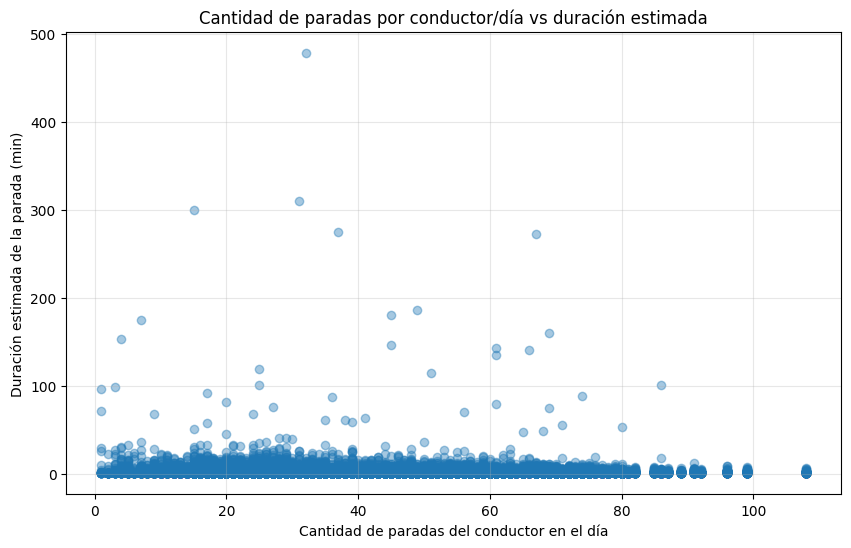

In [41]:
## Gráfico tiempo_serv_prom por cantidad de paradas en la ruta 
import matplotlib.pyplot as plt
import pandas as pd

df_plot = datos_diarios.copy()  # o df_con_comuna / datos_madrugada

df_plot["cantidad_paradas_owner_dia"] = pd.to_numeric(
    df_plot["cantidad_paradas_owner_dia"], errors="coerce"
)

df_plot["duracion_estimada_min"] = pd.to_numeric(
    df_plot["duracion_estimada_min"], errors="coerce"
)

df_plot = df_plot.dropna(
    subset=["cantidad_paradas_owner_dia", "duracion_estimada_min"]
)

plt.figure(figsize=(10, 6))

plt.scatter(
    df_plot["cantidad_paradas_owner_dia"],
    df_plot["duracion_estimada_min"],
    alpha=0.4
)

plt.title("Cantidad de paradas por conductor/día vs duración estimada")
plt.xlabel("Cantidad de paradas del conductor en el día")
plt.ylabel("Duración estimada de la parada (min)")
plt.grid(True, alpha=0.3)

plt.show()

### Probamos criterio de cuartiles para eliminar outliers (no utilizamos este criterio)

In [42]:
datos_diarios = datos_diarios.copy()

# Asegurar tipo numérico
datos_diarios["duracion_estimada_min"] = pd.to_numeric(
    datos_diarios["duracion_estimada_min"],
    errors="coerce"
)

n_original = len(datos_diarios)

# Calcular Q1 y Q3 por hora
datos_diarios["Q1_hora"] = (
    datos_diarios
    .groupby("bloque_horario")["duracion_estimada_min"]
    .transform(lambda x: x.quantile(0.25))
)

datos_diarios["Q3_hora"] = (
    datos_diarios
    .groupby("bloque_horario")["duracion_estimada_min"]
    .transform(lambda x: x.quantile(0.75))
)

# IQR
datos_diarios["IQR_hora"] = (
    datos_diarios["Q3_hora"] - datos_diarios["Q1_hora"]
).fillna(0)

# Límites
datos_diarios["lim_inf"] = datos_diarios["Q1_hora"] - 1.5 * datos_diarios["IQR_hora"]
datos_diarios["lim_sup"] = datos_diarios["Q3_hora"] + 1.5 * datos_diarios["IQR_hora"]

# Filtrar
datos_diarios_sin_outliers_iqr = datos_diarios[
    (datos_diarios["duracion_estimada_min"] >= datos_diarios["lim_inf"]) &
    (datos_diarios["duracion_estimada_min"] <= datos_diarios["lim_sup"])
].copy()

# Métricas
n_actual = len(datos_diarios_sin_outliers_iqr)
n_eliminados = n_original - n_actual
pct = (n_eliminados / n_original) * 100 if n_original > 0 else 0

print("=== DIARIOS | IQR por hora ===")
print(f"Datos originales: {n_original:,}")
print(f"Datos eliminados: {n_eliminados:,}")
print(f"Datos actuales: {n_actual:,}")
print(f"% disminución: {pct:.2f}%")

=== DIARIOS | IQR por hora ===
Datos originales: 40,325
Datos eliminados: 5,157
Datos actuales: 35,168
% disminución: 12.79%


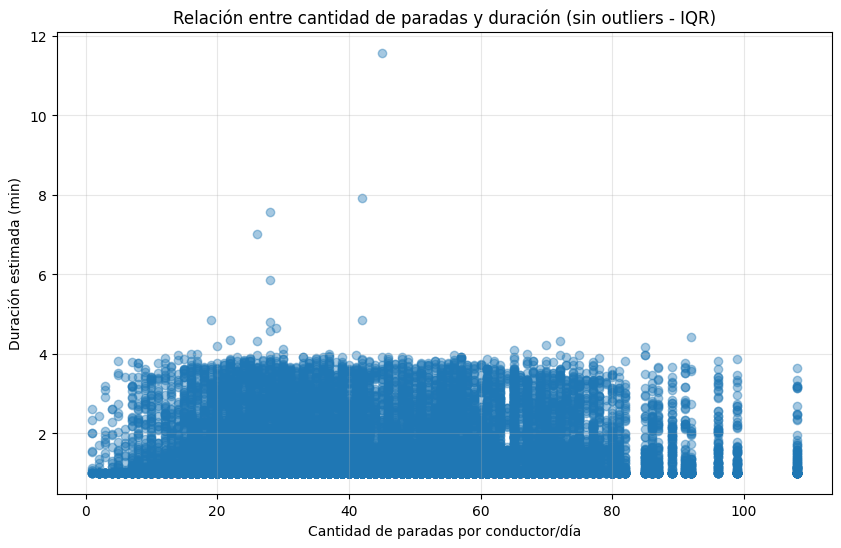

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

df_plot = datos_diarios_sin_outliers_iqr.copy()

df_plot["cantidad_paradas_owner_dia"] = pd.to_numeric(
    df_plot["cantidad_paradas_owner_dia"], errors="coerce"
)

df_plot["duracion_estimada_min"] = pd.to_numeric(
    df_plot["duracion_estimada_min"], errors="coerce"
)

df_plot = df_plot.dropna(
    subset=["cantidad_paradas_owner_dia", "duracion_estimada_min"]
)

plt.figure(figsize=(10, 6))

plt.scatter(
    df_plot["cantidad_paradas_owner_dia"],
    df_plot["duracion_estimada_min"],
    alpha=0.4
)

plt.title("Relación entre cantidad de paradas y duración (sin outliers - IQR)")
plt.xlabel("Cantidad de paradas por conductor/día")
plt.ylabel("Duración estimada (min)")
plt.grid(True, alpha=0.3)

plt.show()

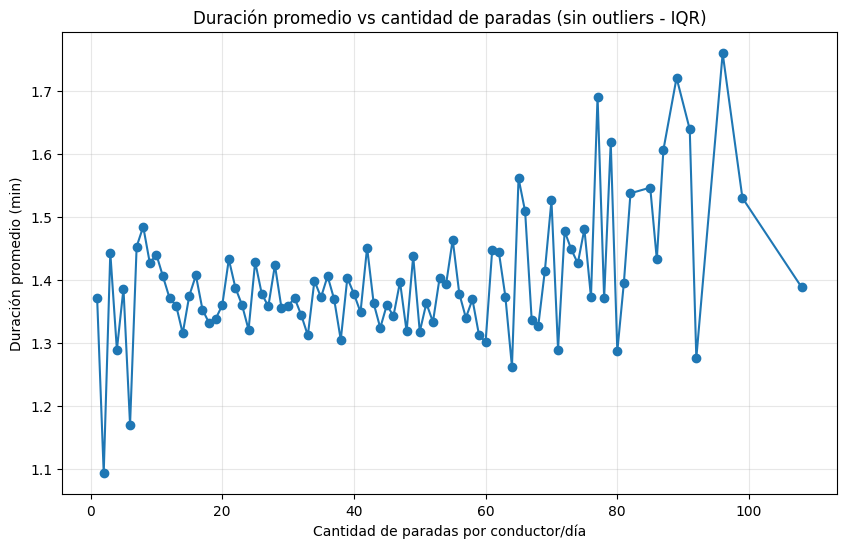

In [44]:
df_promedio = (
    df_plot
    .groupby("cantidad_paradas_owner_dia", as_index=False)["duracion_estimada_min"]
    .mean()
)

plt.figure(figsize=(10, 6))

plt.plot(
    df_promedio["cantidad_paradas_owner_dia"],
    df_promedio["duracion_estimada_min"],
    marker="o"
)

plt.title("Duración promedio vs cantidad de paradas (sin outliers - IQR)")
plt.xlabel("Cantidad de paradas por conductor/día")
plt.ylabel("Duración promedio (min)")
plt.grid(True, alpha=0.3)

plt.show()

<Figure size 4000x600 with 0 Axes>

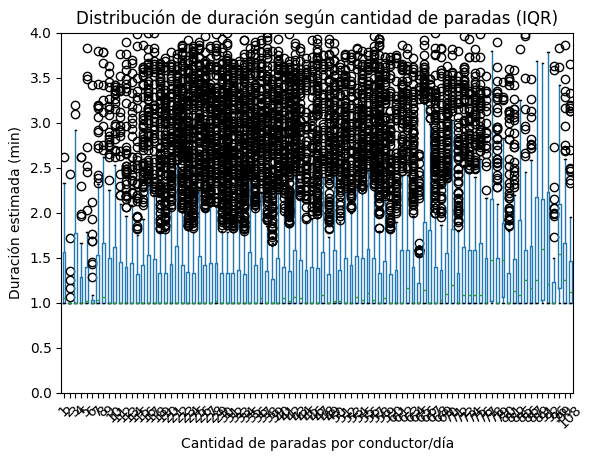

In [45]:
plt.figure(figsize=(40, 6))

df_plot.boxplot(
    column="duracion_estimada_min",
    by="cantidad_paradas_owner_dia",
    grid=False
)

plt.title("Distribución de duración según cantidad de paradas (IQR)")
plt.suptitle("")
plt.xlabel("Cantidad de paradas por conductor/día")
plt.ylabel("Duración estimada (min)")

plt.xticks(rotation=45)
plt.ylim(0, 4)
plt.show()

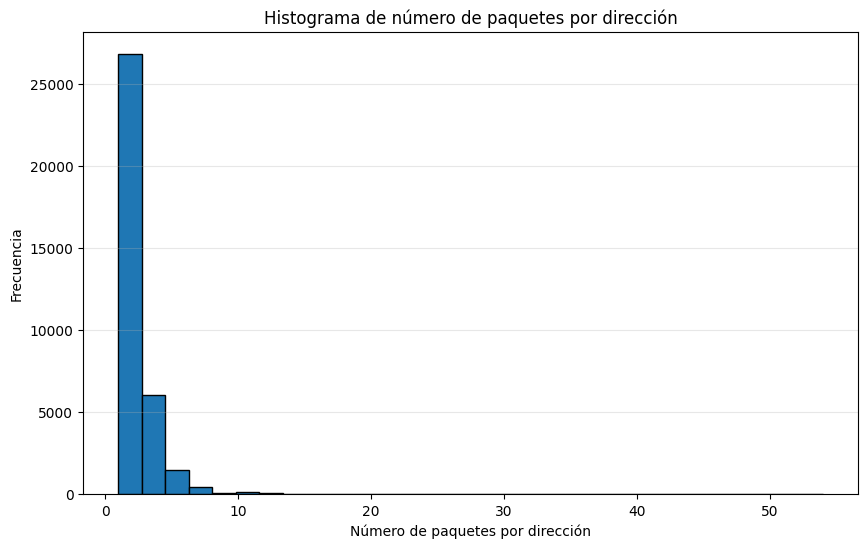

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

df_hist = df_plot.copy()  # o datos_diarios_sin_outliers_iqr / df_con_comuna

df_hist["cantidad_paquetes"] = pd.to_numeric(
    df_hist["cantidad_paquetes"],
    errors="coerce"
)

df_hist = df_hist.dropna(subset=["cantidad_paquetes"])

plt.figure(figsize=(10, 6))

plt.hist(
    df_hist["cantidad_paquetes"],
    bins=30,
    edgecolor="black"
)

plt.title("Histograma de número de paquetes por dirección")
plt.xlabel("Número de paquetes por dirección")
plt.ylabel("Frecuencia")

plt.grid(axis="y", alpha=0.3)

plt.show()

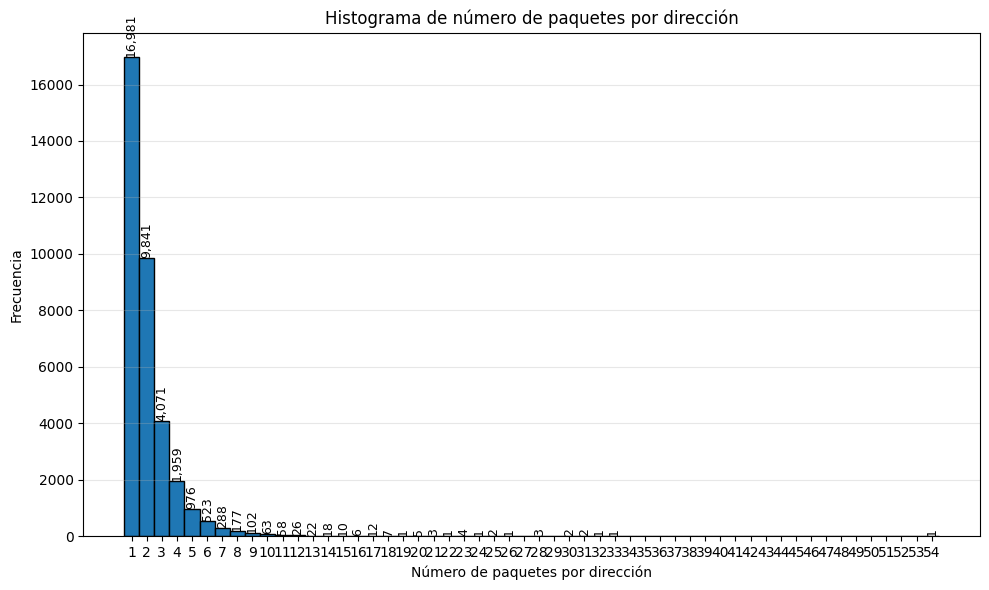

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

df_hist = df_plot.copy()

df_hist["cantidad_paquetes"] = pd.to_numeric(
    df_hist["cantidad_paquetes"],
    errors="coerce"
)

df_hist = df_hist.dropna(subset=["cantidad_paquetes"])

plt.figure(figsize=(10, 6))

counts, bins, patches = plt.hist(
    df_hist["cantidad_paquetes"],
    bins=range(
        int(df_hist["cantidad_paquetes"].min()),
        int(df_hist["cantidad_paquetes"].max()) + 2
    ),
    edgecolor="black",
    align="left"
)

for count, patch in zip(counts, patches):
    if count > 0:
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()

        plt.text(
            x,
            y,
            f"{int(count):,}",
            ha="center",
            va="bottom",
            fontsize=9,
            rotation=90
        )

plt.title("Histograma de número de paquetes por dirección")
plt.xlabel("Número de paquetes por dirección")
plt.ylabel("Frecuencia")

plt.xticks(range(
    int(df_hist["cantidad_paquetes"].min()),
    int(df_hist["cantidad_paquetes"].max()) + 1
))

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Modelos 

In [48]:
# ============================================================
# MODELOS | Dataset limpio con ~1% outliers eliminados
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.formula.api as smf

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# ============================================================
# 1. DATASET BASE
# ============================================================

df_base = datos_diarios_sin_outliers_std.copy()

target = "duracion_estimada_min"

features = [
    "Comuna",
    "dia",
    "bloque_horario",
    "cantidad_paquetes",
    "cantidad_paradas_owner_dia"
]

df_modelos = df_base[features + [target]].copy()

# Tipos numéricos
for col in [target, "cantidad_paquetes", "cantidad_paradas_owner_dia"]:
    df_modelos[col] = pd.to_numeric(df_modelos[col], errors="coerce")

# Categóricas explícitas
categorical_features = ["Comuna", "dia", "bloque_horario"]
numeric_features = ["cantidad_paquetes", "cantidad_paradas_owner_dia"]

for col in categorical_features:
    df_modelos[col] = df_modelos[col].astype("string").fillna("Sin dato")

df_modelos = df_modelos.dropna(subset=[target] + numeric_features)

X = df_modelos[features].copy()
y = df_modelos[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

df_train = X_train.copy()
df_train[target] = y_train

df_test = X_test.copy()
df_test[target] = y_test

resultados = []

def calcular_metricas(y_real, y_pred):
    y_real = np.asarray(y_real)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)

    mask = y_real != 0
    mape = np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100

    return mae, rmse, r2, mape

def guardar_resultados(nombre_modelo, y_train, pred_train, y_test, pred_test):
    for dataset, y_real, y_pred in [
        ("Train", y_train, pred_train),
        ("Test", y_test, pred_test)
    ]:
        mae, rmse, r2, mape = calcular_metricas(y_real, y_pred)

        resultados.append({
            "Modelo": nombre_modelo,
            "Dataset": dataset,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "MAPE_%": mape
        })

# Compatibilidad OneHotEncoder según versión sklearn
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", onehot, categorical_features),
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

# ============================================================
# 2. REGRESIÓN LINEAL SIMPLE
# ============================================================

formula_lineal = """
duracion_estimada_min ~ 
C(Comuna) + 
C(dia) + 
C(bloque_horario) + 
cantidad_paquetes + 
cantidad_paradas_owner_dia
"""

modelo_lineal = smf.ols(
    formula=formula_lineal,
    data=df_train
).fit()

pred_train = modelo_lineal.predict(df_train)
pred_test = modelo_lineal.predict(df_test)

guardar_resultados(
    "Regresión Lineal Simple",
    y_train,
    pred_train,
    y_test,
    pred_test
)

# ============================================================
# 3. REGRESIÓN LINEAL CON INTERACCIONES
# Comuna x bloque_horario
# cantidad_paquetes x Comuna
# ============================================================

formula_interacciones = """
duracion_estimada_min ~ 
C(Comuna) + 
C(dia) + 
C(bloque_horario) + 
cantidad_paquetes + 
cantidad_paradas_owner_dia +
C(Comuna):C(bloque_horario) +
cantidad_paquetes:C(Comuna)
"""

modelo_lineal_interacciones = smf.ols(
    formula=formula_interacciones,
    data=df_train
).fit()

pred_train = modelo_lineal_interacciones.predict(df_train)
pred_test = modelo_lineal_interacciones.predict(df_test)

guardar_resultados(
    "Regresión Lineal con Interacciones",
    y_train,
    pred_train,
    y_test,
    pred_test
)

# ============================================================
# 4. XGBOOST
# Categóricas tratadas correctamente vía One-Hot Encoding
# ============================================================

modelo_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

modelo_xgb.fit(X_train, y_train)

pred_train = modelo_xgb.predict(X_train)
pred_test = modelo_xgb.predict(X_test)

guardar_resultados(
    "XGBoost",
    y_train,
    pred_train,
    y_test,
    pred_test
)

# ============================================================
# 5. CATBOOST
# Categóricas tratadas nativamente
# ============================================================

X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

for col in categorical_features:
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_test_cat[col] = X_test_cat[col].astype(str)

modelo_catboost = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

modelo_catboost.fit(
    X_train_cat,
    y_train,
    cat_features=categorical_features
)

pred_train = modelo_catboost.predict(X_train_cat)
pred_test = modelo_catboost.predict(X_test_cat)

guardar_resultados(
    "CatBoost",
    y_train,
    pred_train,
    y_test,
    pred_test
)

# ============================================================
# 6. TABLA COMPARATIVA FINAL
# ============================================================

resultados_modelos = pd.DataFrame(resultados)

resultados_modelos = resultados_modelos.sort_values(
    by=["Dataset", "RMSE"],
    ascending=[True, True]
)

resultados_modelos

,Modelo,Dataset,MAE,RMSE,R2,MAPE_%
7,CatBoost,Test,0.800809,1.500069,0.341195,37.766648
5,XGBoost,Test,0.798118,1.518317,0.325070,37.203978
1,Regresión Lineal Simple,Test,0.964828,1.713272,0.140617,49.609912
3,Regresión Lineal con Interacciones,Test,0.979726,1.732643,0.121075,51.144821
4,XGBoost,Train,0.734755,1.337417,0.538646,34.713576
6,CatBoost,Train,0.787214,1.501954,0.418146,36.649963
2,Regresión Lineal con Interacciones,Train,0.876231,1.535904,0.391545,45.546895
0,Regresión Lineal Simple,Train,0.954147,1.734063,0.224413,48.920478


In [51]:
# ============================================================
# LASSO CON VARIABLES CATEGÓRICAS COMO DUMMIES
# ============================================================

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
import numpy as np
import pandas as pd

# Compatibilidad sklearn
try:
    onehot_lasso = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
except TypeError:
    onehot_lasso = OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)

preprocessor_lasso = ColumnTransformer(
    transformers=[
        ("cat", onehot_lasso, categorical_features),
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

lasso_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_lasso),
    ("model", LassoCV(
        alphas=np.logspace(-4, 2, 100),
        cv=5,
        random_state=42,
        max_iter=10000,
        n_jobs=-1
    ))
])

lasso_pipeline.fit(X_train, y_train)

# Predicciones
pred_train_lasso = lasso_pipeline.predict(X_train)
pred_test_lasso = lasso_pipeline.predict(X_test)

guardar_resultados(
    "LASSO",
    y_train,
    pred_train_lasso,
    y_test,
    pred_test_lasso
)

# ============================================================
# VARIABLES SELECCIONADAS POR LASSO
# ============================================================

feature_names_lasso = lasso_pipeline.named_steps["preprocessor"].get_feature_names_out()
coef_lasso = lasso_pipeline.named_steps["model"].coef_

lasso_importancia = pd.DataFrame({
    "variable": feature_names_lasso,
    "coeficiente_lasso": coef_lasso
})

lasso_importancia["abs_coeficiente"] = lasso_importancia["coeficiente_lasso"].abs()

lasso_importancia = lasso_importancia.sort_values(
    "abs_coeficiente",
    ascending=False
)

variables_seleccionadas_lasso = lasso_importancia[
    lasso_importancia["coeficiente_lasso"] != 0
].copy()

print("Alpha seleccionado por LASSO:", lasso_pipeline.named_steps["model"].alpha_)
print("Variables originales/dummies totales:", len(feature_names_lasso))
print("Variables seleccionadas por LASSO:", len(variables_seleccionadas_lasso))

variables_seleccionadas_lasso.head(30)

Alpha seleccionado por LASSO: 0.00020092330025650479
Variables originales/dummies totales: 284
Variables seleccionadas por LASSO: 176


,variable,coeficiente_lasso,abs_coeficiente
281,cat__bloque_horario_9,7.572991,7.572991
266,cat__bloque_horario_10,5.486835,5.486835
10,cat__Comuna_Cabildo,1.969998,1.969998
68,cat__Comuna_Florida,1.881948,1.881948
31,cat__Comuna_Chonchi,1.818574,1.818574
56,cat__Comuna_Curepto,-1.777994,1.777994
133,cat__Comuna_Mostazal,1.373500,1.373500
107,cat__Comuna_Llaillay,1.313362,1.313362
33,cat__Comuna_Cobquecura,-1.035487,1.035487
233,cat__Comuna_Teno,-1.028489,1.028489


In [52]:
# ============================================================
# OLS REFIT CON VARIABLES SELECCIONADAS POR LASSO
# ============================================================

X_train_encoded = lasso_pipeline.named_steps["preprocessor"].transform(X_train)
X_test_encoded = lasso_pipeline.named_steps["preprocessor"].transform(X_test)

selected_mask = coef_lasso != 0

X_train_lasso_selected = X_train_encoded[:, selected_mask]
X_test_lasso_selected = X_test_encoded[:, selected_mask]

selected_feature_names = feature_names_lasso[selected_mask]

X_train_lasso_selected_df = pd.DataFrame(
    X_train_lasso_selected,
    columns=selected_feature_names,
    index=X_train.index
)

X_test_lasso_selected_df = pd.DataFrame(
    X_test_lasso_selected,
    columns=selected_feature_names,
    index=X_test.index
)

X_train_lasso_selected_sm = sm.add_constant(X_train_lasso_selected_df)
X_test_lasso_selected_sm = sm.add_constant(X_test_lasso_selected_df)

modelo_ols_lasso_refit = sm.OLS(
    y_train,
    X_train_lasso_selected_sm
).fit()

pred_train_ols_lasso = modelo_ols_lasso_refit.predict(X_train_lasso_selected_sm)
pred_test_ols_lasso = modelo_ols_lasso_refit.predict(X_test_lasso_selected_sm)

guardar_resultados(
    "OLS Refit post-LASSO",
    y_train,
    pred_train_ols_lasso,
    y_test,
    pred_test_ols_lasso
)

# Tabla de significancia
tabla_significancia_lasso = pd.DataFrame({
    "variable": modelo_ols_lasso_refit.params.index,
    "coeficiente": modelo_ols_lasso_refit.params.values,
    "std_error": modelo_ols_lasso_refit.bse.values,
    "t_value": modelo_ols_lasso_refit.tvalues.values,
    "p_value": modelo_ols_lasso_refit.pvalues.values
})

tabla_significancia_lasso["significativa_5pct"] = tabla_significancia_lasso["p_value"] < 0.05

tabla_significancia_lasso = tabla_significancia_lasso.sort_values(
    "p_value",
    ascending=True
)

tabla_significancia_lasso.head(40)

,variable,coeficiente,std_error,t_value,p_value,significativa_5pct
175,num__cantidad_paquetes,0.860787,0.010002,86.062735,0.000000e+00,True
162,cat__bloque_horario_10,5.691804,0.304884,18.668763,2.311089e-77,True
0,const,1.695195,0.096604,17.547961,1.301419e-68,True
176,num__cantidad_paradas_owner_dia,-0.181868,0.011331,-16.049882,9.672387e-58,True
174,cat__bloque_horario_9,8.489446,0.662665,12.811064,1.761089e-37,True
34,cat__Comuna_Curepto,-1.923745,0.282178,-6.817482,9.430727e-12,True
7,cat__Comuna_Cabildo,2.354377,0.412011,5.714354,1.111061e-08,True
71,cat__Comuna_Lo Barnechea,0.462318,0.089432,5.169507,2.361343e-07,True
19,cat__Comuna_Chonchi,2.337625,0.483900,4.830801,1.366188e-06,True
28,cat__Comuna_Copiapó,0.458175,0.096007,4.772301,1.829431e-06,True


In [53]:
resultados_modelos = pd.DataFrame(resultados)

resultados_modelos.sort_values(
    by=["Dataset", "RMSE"],
    ascending=[True, True]
)

,Modelo,Dataset,MAE,RMSE,R2,MAPE_%
7,CatBoost,Test,0.800809,1.500069,0.341195,37.766648
5,XGBoost,Test,0.798118,1.518317,0.325070,37.203978
9,LASSO,Test,0.961779,1.708332,0.145566,49.331027
11,OLS Refit post-LASSO,Test,0.964253,1.712211,0.141681,49.540690
1,Regresión Lineal Simple,Test,0.964828,1.713272,0.140617,49.609912
3,Regresión Lineal con Interacciones,Test,0.979726,1.732643,0.121075,51.144821
4,XGBoost,Train,0.734755,1.337417,0.538646,34.713576
6,CatBoost,Train,0.787214,1.501954,0.418146,36.649963
2,Regresión Lineal con Interacciones,Train,0.876231,1.535904,0.391545,45.546895
0,Regresión Lineal Simple,Train,0.954147,1.734063,0.224413,48.920478


In [54]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42
)

In [55]:
# Si estás en Colab y no tienes Optuna instalado:
# !pip install optuna

import optuna
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [56]:
# ============================================================
# SPLIT PARA OPTUNA
# Train full / Test
# Luego Train / Valid dentro del Train full
# ============================================================

X_train_full, X_test_final, y_train_full, y_test_final = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train_opt, X_valid_opt, y_train_opt, y_valid_opt = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42
)

print("Train opt:", X_train_opt.shape)
print("Valid opt:", X_valid_opt.shape)
print("Train full:", X_train_full.shape)
print("Test final:", X_test_final.shape)

Train opt: (25526, 5)
Valid opt: (6382, 5)
Train full: (31908, 5)
Test final: (7978, 5)


In [57]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluar_modelo(nombre_modelo, y_train, pred_train, y_test, pred_test):
    return pd.DataFrame([
        {
            "Modelo": nombre_modelo,
            "Dataset": "Train",
            "MAE": mean_absolute_error(y_train, pred_train),
            "RMSE": rmse(y_train, pred_train),
            "R2": r2_score(y_train, pred_train),
            "MAPE_%": np.mean(np.abs((y_train - pred_train) / y_train)) * 100
        },
        {
            "Modelo": nombre_modelo,
            "Dataset": "Test",
            "MAE": mean_absolute_error(y_test, pred_test),
            "RMSE": rmse(y_test, pred_test),
            "R2": r2_score(y_test, pred_test),
            "MAPE_%": np.mean(np.abs((y_test - pred_test) / y_test)) * 100
        }
    ])

In [58]:
try:
    onehot_xgb = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_xgb = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ("cat", onehot_xgb, categorical_features),
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

In [59]:
def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1
    }

    model = Pipeline(steps=[
        ("preprocessor", preprocessor_xgb),
        ("model", XGBRegressor(**params))
    ])

    model.fit(X_train_opt, y_train_opt)

    pred_valid = model.predict(X_valid_opt)

    return rmse(y_valid_opt, pred_valid)


study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=30)

print("Mejor RMSE validación XGBoost:", study_xgb.best_value)
print("Mejores parámetros XGBoost:")
study_xgb.best_params

[I 2026-05-19 14:21:11,504] A new study created in memory with name: no-name-0b620c88-09d0-46e9-aac1-8f409b9db094
[I 2026-05-19 14:21:14,339] Trial 0 finished with value: 1.5794543635323832 and parameters: {'n_estimators': 941, 'max_depth': 10, 'learning_rate': 0.0148001645131319, 'subsample': 0.9716676535596267, 'colsample_bytree': 0.7361224795814657, 'min_child_weight': 4, 'gamma': 4.735480996350019, 'reg_alpha': 9.180821001040863e-07, 'reg_lambda': 1.166958013327909}. Best is trial 0 with value: 1.5794543635323832.
[I 2026-05-19 14:21:16,226] Trial 1 finished with value: 1.5338806451479718 and parameters: {'n_estimators': 675, 'max_depth': 6, 'learning_rate': 0.03168645946839945, 'subsample': 0.7515331744009535, 'colsample_bytree': 0.852907598398813, 'min_child_weight': 17, 'gamma': 0.3781085054438643, 'reg_alpha': 0.03749179102597789, 'reg_lambda': 4.7026444616061904e-05}. Best is trial 1 with value: 1.5338806451479718.
[I 2026-05-19 14:21:17,510] Trial 2 finished with value: 1.540

Mejor RMSE validación XGBoost: 1.5277352331624665
Mejores parámetros XGBoost:


{'n_estimators': 754,
 'max_depth': 7,
 'learning_rate': 0.057165052980778015,
 'subsample': 0.8433265514335352,
 'colsample_bytree': 0.8372479259689849,
 'min_child_weight': 18,
 'gamma': 3.4522129337369556,
 'reg_alpha': 7.596778224775808,
 'reg_lambda': 0.1050884742421839}

In [60]:
best_params_xgb = study_xgb.best_params.copy()

best_params_xgb.update({
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1
})

modelo_xgb_optimizado = Pipeline(steps=[
    ("preprocessor", preprocessor_xgb),
    ("model", XGBRegressor(**best_params_xgb))
])

modelo_xgb_optimizado.fit(X_train_full, y_train_full)

pred_train_xgb_opt = modelo_xgb_optimizado.predict(X_train_full)
pred_test_xgb_opt = modelo_xgb_optimizado.predict(X_test_final)

resultados_xgb_opt = evaluar_modelo(
    "XGBoost Optimizado",
    y_train_full,
    pred_train_xgb_opt,
    y_test_final,
    pred_test_xgb_opt
)

resultados_xgb_opt

,Modelo,Dataset,MAE,RMSE,R2,MAPE_%
0,XGBoost Optimizado,Train,0.764345,1.443553,0.462515,35.714009
1,XGBoost Optimizado,Test,0.803384,1.530577,0.314126,37.261877


In [61]:
X_train_opt_cat = X_train_opt.copy()
X_valid_opt_cat = X_valid_opt.copy()
X_train_full_cat = X_train_full.copy()
X_test_final_cat = X_test_final.copy()

for col in categorical_features:
    X_train_opt_cat[col] = X_train_opt_cat[col].astype(str)
    X_valid_opt_cat[col] = X_valid_opt_cat[col].astype(str)
    X_train_full_cat[col] = X_train_full_cat[col].astype(str)
    X_test_final_cat[col] = X_test_final_cat[col].astype(str)


def objective_catboost(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 300, 1200),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 20.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
        "loss_function": "RMSE",
        "random_seed": 42,
        "verbose": 0
    }

    model = CatBoostRegressor(**params)

    model.fit(
        X_train_opt_cat,
        y_train_opt,
        cat_features=categorical_features,
        eval_set=(X_valid_opt_cat, y_valid_opt),
        verbose=0
    ) 

    pred_valid = model.predict(X_valid_opt_cat)

    return rmse(y_valid_opt, pred_valid)


study_catboost = optuna.create_study(direction="minimize")
study_catboost.optimize(objective_catboost, n_trials=30)

print("Mejor RMSE validación CatBoost:", study_catboost.best_value)
print("Mejores parámetros CatBoost:")
study_catboost.best_params

[I 2026-05-19 14:22:53,158] A new study created in memory with name: no-name-a210a266-7aa9-4c5b-8f93-10efb3cf91aa
[I 2026-05-19 14:23:49,372] Trial 0 finished with value: 1.5100408000891987 and parameters: {'iterations': 835, 'depth': 7, 'learning_rate': 0.05498096162759014, 'l2_leaf_reg': 0.00159170366933853, 'random_strength': 1.6344394750876283, 'bagging_temperature': 3.8120424793919288}. Best is trial 0 with value: 1.5100408000891987.
[I 2026-05-19 14:24:32,670] Trial 1 finished with value: 1.5130752205225446 and parameters: {'iterations': 510, 'depth': 10, 'learning_rate': 0.03044877556657977, 'l2_leaf_reg': 0.04400996921110931, 'random_strength': 0.0077826959970787105, 'bagging_temperature': 4.737411506520589}. Best is trial 0 with value: 1.5100408000891987.
[I 2026-05-19 14:25:08,404] Trial 2 finished with value: 1.547606641806109 and parameters: {'iterations': 1064, 'depth': 4, 'learning_rate': 0.019405117224544053, 'l2_leaf_reg': 0.004202694079098668, 'random_strength': 0.0409

Mejor RMSE validación CatBoost: 1.5028060362284765
Mejores parámetros CatBoost:


{'iterations': 1118,
 'depth': 9,
 'learning_rate': 0.055386071392577056,
 'l2_leaf_reg': 0.2572288560333817,
 'random_strength': 1.4432115603117492,
 'bagging_temperature': 4.52997377391699}

In [62]:
best_params_catboost = study_catboost.best_params.copy()

best_params_catboost.update({
    "loss_function": "RMSE",
    "random_seed": 42,
    "verbose": 0
})

modelo_catboost_optimizado = CatBoostRegressor(**best_params_catboost)

modelo_catboost_optimizado.fit(
    X_train_full_cat,
    y_train_full,
    cat_features=categorical_features,
    verbose=0
)

pred_train_cat_opt = modelo_catboost_optimizado.predict(X_train_full_cat)
pred_test_cat_opt = modelo_catboost_optimizado.predict(X_test_final_cat)

resultados_catboost_opt = evaluar_modelo(
    "CatBoost Optimizado",
    y_train_full,
    pred_train_cat_opt,
    y_test_final,
    pred_test_cat_opt
)

resultados_catboost_opt

,Modelo,Dataset,MAE,RMSE,R2,MAPE_%
0,CatBoost Optimizado,Train,0.736432,1.383647,0.506200,35.193720
1,CatBoost Optimizado,Test,0.813193,1.502966,0.338649,39.166377


In [63]:
resultados_optimizados = pd.concat(
    [
        resultados_modelos,
        resultados_xgb_opt,
        resultados_catboost_opt
    ],
    ignore_index=True
)

resultados_optimizados.sort_values(
    by=["Dataset", "RMSE"],
    ascending=[True, True]
)

,Modelo,Dataset,MAE,RMSE,R2,MAPE_%
7,CatBoost,Test,0.800809,1.500069,0.341195,37.766648
15,CatBoost Optimizado,Test,0.813193,1.502966,0.338649,39.166377
5,XGBoost,Test,0.798118,1.518317,0.325070,37.203978
13,XGBoost Optimizado,Test,0.803384,1.530577,0.314126,37.261877
9,LASSO,Test,0.961779,1.708332,0.145566,49.331027
11,OLS Refit post-LASSO,Test,0.964253,1.712211,0.141681,49.540690
1,Regresión Lineal Simple,Test,0.964828,1.713272,0.140617,49.609912
3,Regresión Lineal con Interacciones,Test,0.979726,1.732643,0.121075,51.144821
4,XGBoost,Train,0.734755,1.337417,0.538646,34.713576
14,CatBoost Optimizado,Train,0.736432,1.383647,0.506200,35.193720


## Veamos cuales son las variables relevantes por modelo

In [64]:
modelo_lineal.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     duracion_estimada_min   R-squared:                       0.224
Model:                               OLS   Adj. R-squared:                  0.217
Method:                    Least Squares   F-statistic:                     32.22
Date:                   Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                           15:28:38   Log-Likelihood:                -62840.
No. Observations:                  31908   AIC:                         1.262e+05
Df Residuals:                      31623   BIC:                         1.286e+05
Df Model:                            284                                         
Covariance Type:               nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             1.1571      0.278      4.169      0.000       0.613       1.701
C(Comuna)[T.Alhué]                   -0.4026      0.340     -1.186      0.236      -1.068       0.263
C(Comuna)[T.Alto Hospicio]            0.3430      0.290      1.183      0.237      -0.225       0.911
C(Comuna)[T.Ancud]                    0.0443      0.603      0.073      0.941      -1.138       1.226
C(Comuna)[T.Angol]                    0.0592      0.279      0.213      0.832      -0.487       0.605
C(Comuna)[T.Antofagasta]              0.0256      0.266      0.096      0.923      -0.495       0.546
C(Comuna)[T.Arauco]                  -0.0937      0.322     -0.291      0.771      -0.725       0.538
C(Comuna)[T.Arica]                    0.3981      0.264      1.507      0.132      -0.120       0.916
C(Comuna)[T.Aysén]                   -0.3159      0.513     -0.616      0.538      -1.321       0.689
C(Comuna)[T.Buin]                    -0.0420      0.297     -0.141      0.888      -0.625       0.541
C(Comuna)[T.Bulnes]                   0.1324      0.377      0.351      0.725      -0.606       0.871
C(Comuna)[T.Cabildo]                  2.3941      0.479      4.999      0.000       1.455       3.333
C(Comuna)[T.Cabrero]                  0.4393      0.390      1.127      0.260      -0.325       1.203
C(Comuna)[T.Calama]                  -0.2702      0.264     -1.025      0.305      -0.787       0.246
C(Comuna)[T.Caldera]                  0.3746      0.426      0.879      0.379      -0.460       1.210
C(Comuna)[T.Calera]                   0.1273      0.310      0.411      0.681      -0.481       0.735
C(Comuna)[T.Calera de Tango]          0.4698      0.406      1.157      0.247      -0.326       1.266
C(Comuna)[T.Calle Larga]              0.3674      0.500      0.735      0.462      -0.612       1.347
C(Comuna)[T.Carahue]                  0.1501      0.421      0.356      0.722      -0.676       0.976
C(Comuna)[T.Cartagena]                0.2324      0.460      0.505      0.614      -0.670       1.134
C(Comuna)[T.Casablanca]               0.0370      0.401      0.092      0.927      -0.749       0.823
C(Comuna)[T.Catemu]                   0.9351      0.421      2.221      0.026       0.110       1.760
C(Comuna)[T.Cauquenes]               -0.1647      0.279     -0.591      0.555      -0.711       0.382
C(Comuna)[T.Cañete]                  -0.3603      0.421     -0.857      0.392      -1.185       0.464
C(Comuna)[T.Cerrillos]                0.2933      0.305      0.962      0.336      -0.304       0.891
C(Comuna)[T.Cerro Navia]              0.1751      0.273      0.642      0.521      -0.360       0.710
C(Comuna)[T.Chañaral]                 0.4674      0.906      0.516      0.606      -1.308   

In [65]:
tabla_ols = pd.DataFrame({
    "variable": modelo_lineal.params.index,
    "coeficiente": modelo_lineal.params.values,
    "std_error": modelo_lineal.bse.values,
    "t_value": modelo_lineal.tvalues.values,
    "p_value": modelo_lineal.pvalues.values
})

tabla_ols["significativa_5pct"] = tabla_ols["p_value"] < 0.05

tabla_ols = tabla_ols.sort_values("p_value")

tabla_ols.head(40)

,variable,coeficiente,std_error,t_value,p_value,significativa_5pct
283,cantidad_paquetes,0.376888,0.004398,85.703679,0.000000e+00,True
267,C(bloque_horario)[T.10],5.698195,0.319458,17.837088,8.104624e-71,True
284,cantidad_paradas_owner_dia,-0.009346,0.000588,-15.883806,1.358821e-56,True
282,C(bloque_horario)[T.9],8.500005,0.669659,12.693030,7.950461e-37,True
57,C(Comuna)[T.Curepto],-1.882678,0.372112,-5.059443,4.228339e-07,True
11,C(Comuna)[T.Cabildo],2.394103,0.478903,4.999143,5.789294e-07,True
32,C(Comuna)[T.Chonchi],2.378279,0.541892,4.388846,1.143225e-05,True
0,Intercept,1.157081,0.277571,4.168597,3.072955e-05,True
69,C(Comuna)[T.Florida],3.545006,0.905490,3.915013,9.058895e-05,True
134,C(Comuna)[T.Mostazal],1.768231,0.460861,3.836796,1.248922e-04,True


In [67]:
variables_seleccionadas_lasso.head(40)

,variable,coeficiente_lasso,abs_coeficiente
281,cat__bloque_horario_9,7.572991,7.572991
266,cat__bloque_horario_10,5.486835,5.486835
10,cat__Comuna_Cabildo,1.969998,1.969998
68,cat__Comuna_Florida,1.881948,1.881948
31,cat__Comuna_Chonchi,1.818574,1.818574
56,cat__Comuna_Curepto,-1.777994,1.777994
133,cat__Comuna_Mostazal,1.373500,1.373500
107,cat__Comuna_Llaillay,1.313362,1.313362
33,cat__Comuna_Cobquecura,-1.035487,1.035487
233,cat__Comuna_Teno,-1.028489,1.028489


In [68]:
modelo_xgb_optimizado.named_steps["model"]

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8372479259689849
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [69]:
xgb_model = modelo_xgb_optimizado.named_steps["model"]

feature_names_xgb = modelo_xgb_optimizado.named_steps[
    "preprocessor"
].get_feature_names_out()

xgb_importance = pd.DataFrame({
    "variable": feature_names_xgb,
    "importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    "importance",
    ascending=False
)

xgb_importance.head(30)

,variable,importance
285,num__cantidad_paquetes,0.085891
174,cat__Comuna_Pudahuel,0.041611
269,cat__bloque_horario_10,0.034755
13,cat__Comuna_Calama,0.020032
110,cat__Comuna_Lo Barnechea,0.019895
286,num__cantidad_paradas_owner_dia,0.017789
278,cat__bloque_horario_19,0.016434
263,cat__dia_martes,0.016293
57,cat__Comuna_Curepto,0.016067
276,cat__bloque_horario_17,0.014862


In [70]:
cat_importance = pd.DataFrame({
    "variable": modelo_catboost_optimizado.feature_names_,
    "importance": modelo_catboost_optimizado.get_feature_importance()
})

cat_importance = cat_importance.sort_values(
    "importance",
    ascending=False
)

cat_importance

,variable,importance
3,cantidad_paquetes,27.459961
0,Comuna,20.727114
2,bloque_horario,20.649265
1,dia,15.924980
4,cantidad_paradas_owner_dia,15.238681


In [73]:
%pip install shap

     ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
     --- ----------------------------------- 51.2/547.0 kB 1.3 MB/s eta 0:00:01
     ----- --------------------------------- 71.7/547.0 kB 1.3 MB/s eta 0:00:01
     -------- ----------------------------- 122.9/547.0 kB 1.0 MB/s eta 0:00:01
     -------------- ----------------------- 204.8/547.0 kB 1.1 MB/s eta 0:00:01
     ------------------ ------------------- 266.2/547.0 kB 1.4 MB/s eta 0:00:01
     ------------------------ ------------- 348.2/547.0 kB 1.4 MB/s eta 0:00:01
     ----------------------------- -------- 430.1/547.0 kB 1.4 MB/s eta 0:00:01
     ----------------------------------- -- 512.0/547.0 kB 1.5 MB/s eta 0:00:01
     -------------------------------------- 547.0/547.0 kB 1.4 MB/s eta 0:00:00
     ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
     - -------------------------------------- 0.1/2.7 MB 975.2 kB


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
# ============================================================
# SHAP PARA CATBOOST OPTIMIZADO
# ============================================================

# Si estás en Colab y no tienes shap:
# !pip install shap

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Muestra para no hacer SHAP sobre todo el dataset
X_shap = X_test_final_cat.copy()

# Opcional: limitar muestra para que corra más rápido
X_shap_sample = X_shap.sample(
    n=min(3000, len(X_shap)),
    random_state=42
)

# Crear explainer
explainer_cat = shap.TreeExplainer(modelo_catboost_optimizado)

# Calcular valores SHAP
shap_values_cat = explainer_cat.shap_values(X_shap_sample)

# ============================================================
# 1. IMPORTANCIA GLOBAL PROMEDIO
# ============================================================

shap_importance_cat = pd.DataFrame({
    "variable": X_shap_sample.columns,
    "mean_abs_shap": np.abs(shap_values_cat).mean(axis=0)
})

shap_importance_cat = shap_importance_cat.sort_values(
    "mean_abs_shap",
    ascending=False
)

shap_importance_cat

,variable,mean_abs_shap
3,cantidad_paquetes,0.675341
4,cantidad_paradas_owner_dia,0.183575
1,dia,0.128256
0,Comuna,0.106807
2,bloque_horario,0.103416


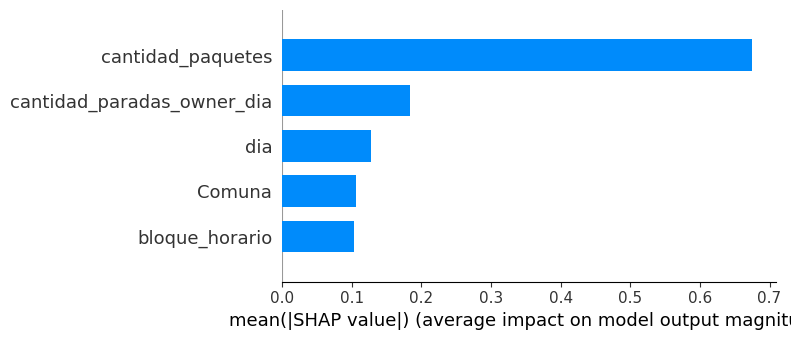

In [75]:
# ============================================================
# 2. GRÁFICO DE IMPORTANCIA GLOBAL
# ============================================================

shap.summary_plot(
    shap_values_cat,
    X_shap_sample,
    plot_type="bar"
)

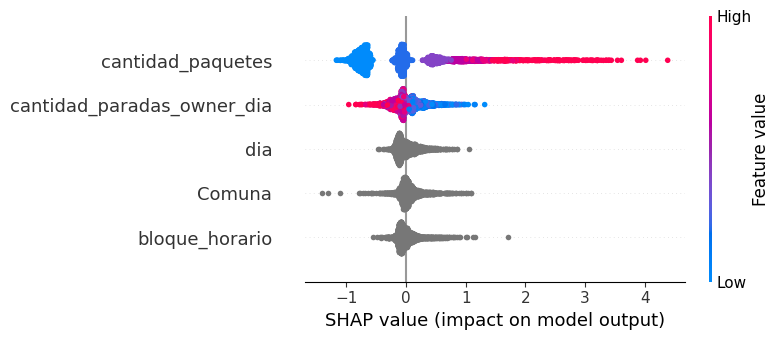

In [76]:
# ============================================================
# 3. SUMMARY PLOT
# Muestra importancia + dirección del efecto
# ============================================================

shap.summary_plot(
    shap_values_cat,
    X_shap_sample
)

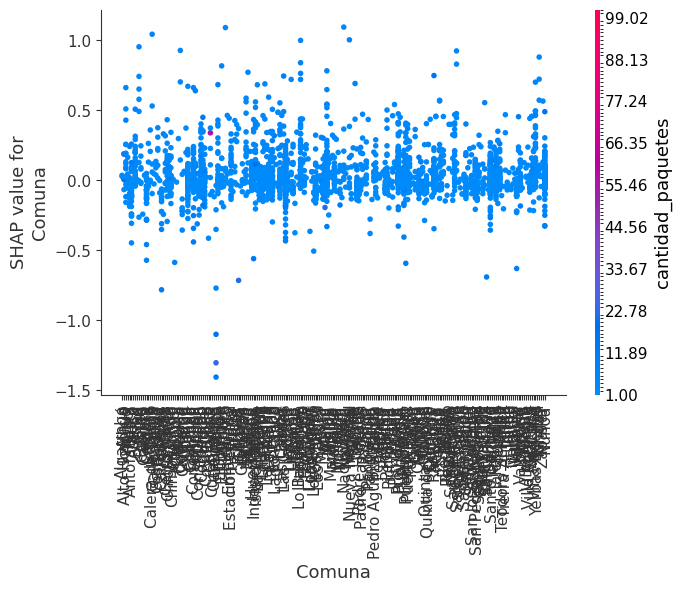

In [77]:
shap.dependence_plot("Comuna", shap_values_cat, X_shap_sample)

In [80]:
# ============================================================
# DRILL-DOWN SHAP POR COMUNA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# índice de la variable comuna dentro del array SHAP
idx_comuna = list(X_shap_sample.columns).index("Comuna")

# construir dataframe
drilldown_comuna = pd.DataFrame({
    "Comuna": X_shap_sample["Comuna"].values,
    "shap_comuna": shap_values_cat[:, idx_comuna]
})

# agregación por comuna
resumen_comuna = (
    drilldown_comuna
    .groupby("Comuna")
    .agg(
        impacto_promedio=("shap_comuna", "mean"),
        impacto_abs_promedio=("shap_comuna", lambda x: np.mean(np.abs(x))),
        n_obs=("shap_comuna", "count")
    )
    .reset_index()
)

# filtrar comunas con pocas observaciones para evitar ruido
resumen_comuna = resumen_comuna[
    resumen_comuna["n_obs"] >= 30
]

# ordenar
resumen_comuna = resumen_comuna.sort_values(
    "impacto_promedio",
    ascending=False
)

resumen_comuna

,Comuna,impacto_promedio,impacto_abs_promedio,n_obs
95,Lo Barnechea,0.205502,0.211624,49
220,Viña del Mar,0.166815,0.176957,42
42,Copiapó,0.118716,0.135439,37
109,Maipú,0.087435,0.126019,93
147,Providencia,0.080507,0.107262,88
152,Puerto Montt,0.076115,0.110201,32
84,Lampa,0.075298,0.116502,32
201,Temuco,0.048066,0.060898,39
43,Coquimbo,0.044298,0.089180,37
166,Rancagua,0.038771,0.079904,51


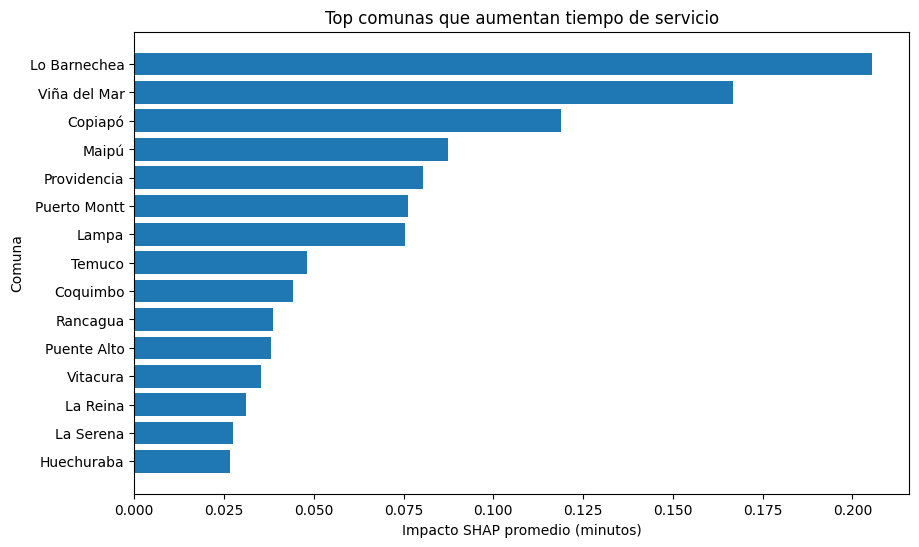

In [81]:
top_aumentan = resumen_comuna.head(15)

plt.figure(figsize=(10,6))
plt.barh(
    top_aumentan["Comuna"],
    top_aumentan["impacto_promedio"]
)

plt.xlabel("Impacto SHAP promedio (minutos)")
plt.ylabel("Comuna")
plt.title("Top comunas que aumentan tiempo de servicio")
plt.gca().invert_yaxis()
plt.show()

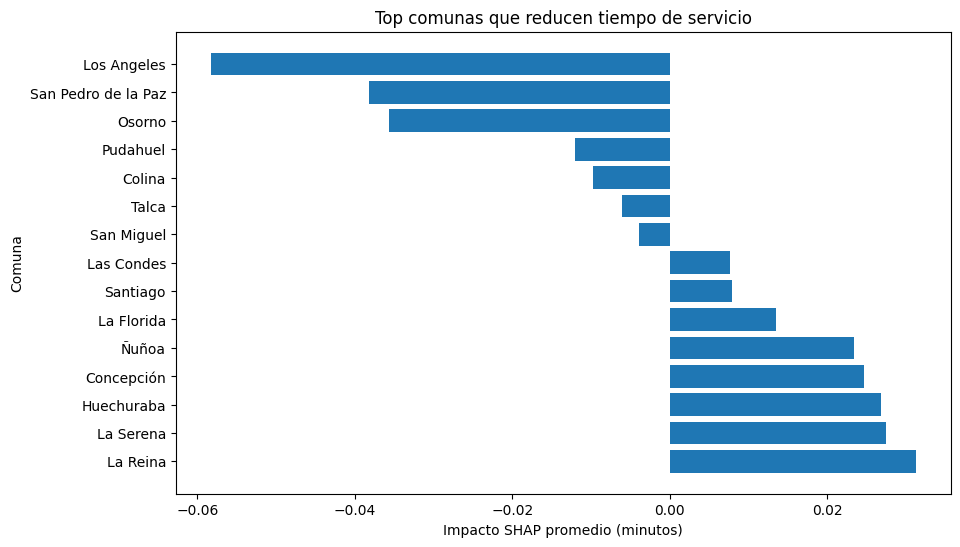

In [82]:
top_reducen = resumen_comuna.tail(15)

plt.figure(figsize=(10,6))
plt.barh(
    top_reducen["Comuna"],
    top_reducen["impacto_promedio"]
)

plt.xlabel("Impacto SHAP promedio (minutos)")
plt.ylabel("Comuna")
plt.title("Top comunas que reducen tiempo de servicio")
plt.show()

In [84]:
# ============================================================
# DRILL-DOWN SHAP POR BLOQUE HORARIO
# ============================================================

idx_bloque = list(X_shap_sample.columns).index("bloque_horario")

drilldown_bloque = pd.DataFrame({
    "bloque_horario": X_shap_sample["bloque_horario"].values,
    "shap_bloque": shap_values_cat[:, idx_bloque]
})

resumen_bloque = (
    drilldown_bloque
    .groupby("bloque_horario")
    .agg(
        impacto_promedio=("shap_bloque", "mean"),
        impacto_abs_promedio=("shap_bloque", lambda x: np.mean(np.abs(x))),
        n_obs=("shap_bloque", "count")
    )
    .reset_index()
)

# ordenar correctamente numéricamente
resumen_bloque["bloque_horario"] = pd.to_numeric(
    resumen_bloque["bloque_horario"],
    errors="coerce"
)

resumen_bloque = resumen_bloque.sort_values("bloque_horario")

resumen_bloque

,bloque_horario,impacto_promedio,impacto_abs_promedio,n_obs
0,0,-0.007955,0.129041,27
1,1,0.106329,0.120689,15
12,2,0.059830,0.059830,4
2,10,0.290635,0.290635,5
3,11,0.271137,0.296348,20
4,12,-0.076368,0.136501,101
5,13,-0.003089,0.103509,276
6,14,-0.044401,0.082676,394
7,15,-0.038306,0.085344,452
8,16,-0.038011,0.084754,436


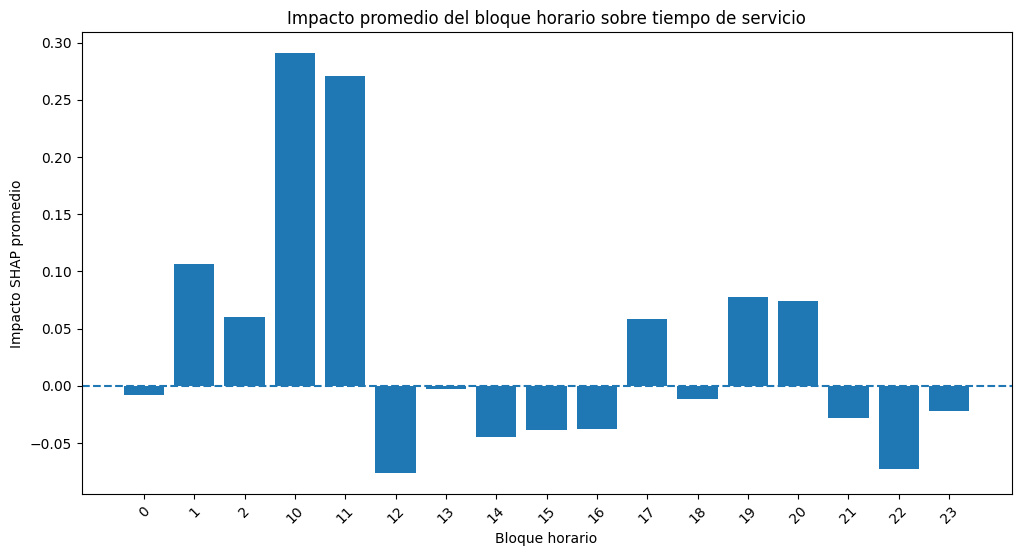

In [85]:
plt.figure(figsize=(12,6))

plt.bar(
    resumen_bloque["bloque_horario"].astype(str),
    resumen_bloque["impacto_promedio"]
)

plt.axhline(0, linestyle="--")

plt.xlabel("Bloque horario")
plt.ylabel("Impacto SHAP promedio")
plt.title("Impacto promedio del bloque horario sobre tiempo de servicio")

plt.xticks(rotation=45)
plt.show()

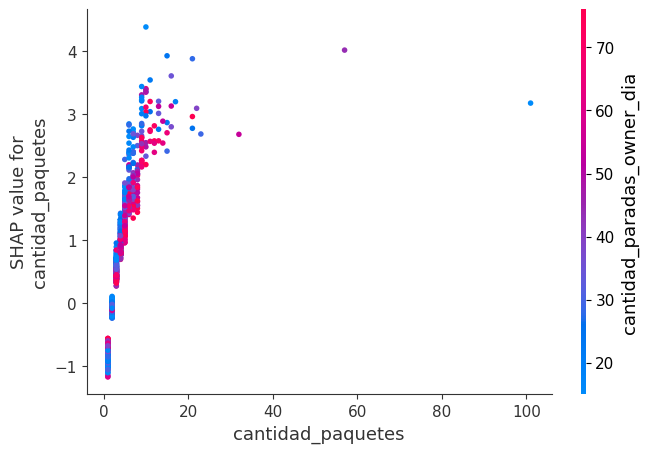

In [78]:
shap.dependence_plot("cantidad_paquetes", shap_values_cat, X_shap_sample)

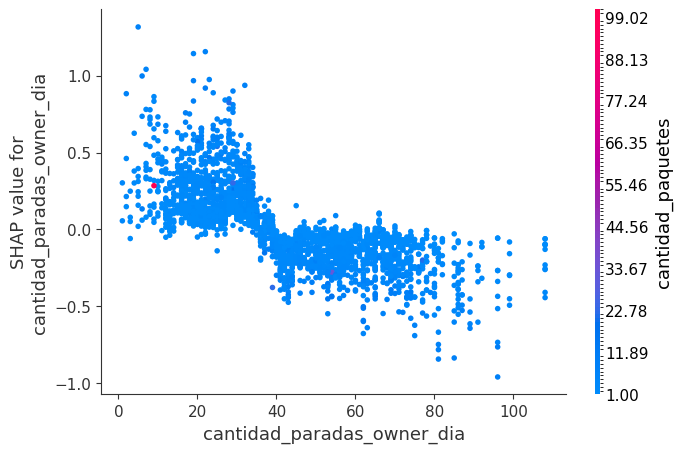

In [79]:
shap.dependence_plot("cantidad_paradas_owner_dia", shap_values_cat, X_shap_sample)

## Cuanto tiempo viajamos y cuando tiempo servimos?

In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# COPIA SEGURA
# ============================================================

df_rutas = df_con_comuna.copy()

# ============================================================
# FORMATO DATETIME
# ============================================================

df_rutas["created_inicio"] = pd.to_datetime(
    df_rutas["created_inicio"],
    errors="coerce"
)

# duración numérica
df_rutas["duracion_estimada_min"] = pd.to_numeric(
    df_rutas["duracion_estimada_min"],
    errors="coerce"
)

# ============================================================
# CREAR TIMESTAMP DE FIN DE ENTREGA
# ============================================================

df_rutas["created_fin_entrega"] = (
    df_rutas["created_inicio"] +
    pd.to_timedelta(df_rutas["duracion_estimada_min"], unit="m")
)

# ============================================================
# AGRUPACIÓN POR USUARIO Y DÍA
# ============================================================

resumen_rutas = (
    df_rutas
    .groupby(["owner_id", "dia"])
    .agg(
        inicio_ruta=("created_inicio", "min"),
        fin_ruta=("created_fin_entrega", "max"),
        tiempo_entregando_min=("duracion_estimada_min", "sum"),
        cantidad_paradas=("parada_agrupada_detectada_id", "count")
    )
    .reset_index()
)

# ============================================================
# TIEMPO TOTAL DE RUTA
# ============================================================

resumen_rutas["tiempo_total_ruta_min"] = (
    (
        resumen_rutas["fin_ruta"] -
        resumen_rutas["inicio_ruta"]
    )
    .dt.total_seconds() / 60
)

# ============================================================
# TIEMPO MANEJANDO
# ============================================================

resumen_rutas["tiempo_manejando_min"] = (
    resumen_rutas["tiempo_total_ruta_min"] -
    resumen_rutas["tiempo_entregando_min"]
)

# Evitar negativos raros
resumen_rutas["tiempo_manejando_min"] = (
    resumen_rutas["tiempo_manejando_min"]
    .clip(lower=0)
)

# ============================================================
# PORCENTAJES
# ============================================================

resumen_rutas["pct_entregando"] = (
    resumen_rutas["tiempo_entregando_min"] /
    resumen_rutas["tiempo_total_ruta_min"]
) * 100

resumen_rutas["pct_manejando"] = (
    resumen_rutas["tiempo_manejando_min"] /
    resumen_rutas["tiempo_total_ruta_min"]
) * 100

# ============================================================
# REDONDEO
# ============================================================

columnas_redondear = [
    "tiempo_entregando_min",
    "tiempo_total_ruta_min",
    "tiempo_manejando_min",
    "pct_entregando",
    "pct_manejando"
]

resumen_rutas[columnas_redondear] = (
    resumen_rutas[columnas_redondear]
    .round(2)
)

# ============================================================
# RESULTADO
# ============================================================

resumen_rutas.head()

,owner_id,dia,inicio_ruta,fin_ruta,tiempo_entregando_min,cantidad_paradas,tiempo_total_ruta_min,tiempo_manejando_min,pct_entregando,pct_manejando
0,324024,jueves,2025-09-25 13:42:20+00:00,2025-09-25 20:26:14+00:00,109.53,25,403.90,294.37,27.12,72.88
1,324024,lunes,2025-09-22 14:14:53+00:00,2025-09-29 16:45:57+00:00,104.17,39,10231.07,10126.90,1.02,98.98
2,324024,sábado,2025-09-27 12:55:43+00:00,2025-09-27 20:53:44.000000002+00:00,51.32,24,478.02,426.70,10.74,89.26
3,324024,viernes,2025-09-26 13:19:34+00:00,2025-09-26 18:30:10.999999998+00:00,99.15,21,310.62,211.47,31.92,68.08
4,335656,jueves,2025-09-25 12:52:49+00:00,2025-09-25 20:26:09+00:00,93.82,47,453.33,359.52,20.69,79.31


In [ ]:
# ============================================================
# TABLA RESUMEN POR DÍA
# ============================================================

tabla_por_dia = (
    resumen_rutas
    .groupby("dia")
    .agg(
        rutas=("owner_id", "count"),

        tiempo_total_ruta_min_promedio=(
            "tiempo_total_ruta_min",
            "mean"
        ),

        tiempo_entregando_min_promedio=(
            "tiempo_entregando_min",
            "mean"
        ),

        tiempo_manejando_min_promedio=(
            "tiempo_manejando_min",
            "mean"
        ),

        pct_entregando_promedio=(
            "pct_entregando",
            "mean"
        ),

        pct_manejando_promedio=(
            "pct_manejando",
            "mean"
        )
    )
    .reset_index()
)

# ============================================================
# REDONDEAR
# ============================================================

columnas_redondear = [
    "tiempo_total_ruta_min_promedio",
    "tiempo_entregando_min_promedio",
    "tiempo_manejando_min_promedio",
    "pct_entregando_promedio",
    "pct_manejando_promedio"
]

tabla_por_dia[columnas_redondear] = (
    tabla_por_dia[columnas_redondear]
    .round(2)
)

# ============================================================
# ORDEN SEMANAL
# ============================================================

orden_dias = [
    "lunes",
    "martes",
    "miércoles",
    "jueves",
    "viernes",
    "sábado",
    "domingo"
]

tabla_por_dia["dia"] = pd.Categorical(
    tabla_por_dia["dia"],
    categories=orden_dias,
    ordered=True
)

tabla_por_dia = tabla_por_dia.sort_values("dia")

# ============================================================
# RESULTADO
# ============================================================


tabla_por_dia

,dia,rutas,tiempo_total_ruta_min_promedio,tiempo_entregando_min_promedio,tiempo_manejando_min_promedio,pct_entregando_promedio,pct_manejando_promedio
2,lunes,218,3072.86,61.05,3011.81,18.69,81.63
3,martes,261,360.41,83.41,277.00,23.85,76.15
4,miércoles,252,325.02,69.46,255.56,22.45,77.55
1,jueves,185,340.78,71.03,269.75,22.57,77.43
6,viernes,183,336.91,65.65,271.26,22.69,77.36
5,sábado,161,323.04,71.03,252.02,23.41,76.59
0,domingo,13,275.59,61.34,214.24,22.04,77.96
